# Robot Current Monitoring with Linear Regression

**Our question:** Is a robot joint drawing more electrical current than our model expects, and does that extra current last long enough to deserve attention?

The robot has eight measured axes (joints). Each reading tells us the time and the current drawn by each axis. We fit one straight-line model for each axis (Time → Axis #1–#8), study where the real readings sit above or below that line, and turn those gaps into Alert and Error rules.

### Our route through the project

| Step | What we do | Why it matters |
|---|---|---|
| Read and check | Pull historical measurements from Neon PostgreSQL | Models need trustworthy input |
| Split | Earlier 80% for training, later 20% for calibration | We learn from the past before checking later behavior |
| Scale and fit | Standardize, then fit eight lines on **active** readings | Each axis gets its own time-to-current model |
| Compare | Residuals, outlier counts, and how long deviations last | This evidence sets MinC, MaxC and T |
| Test | Generate synthetic readings, stream them through Neon, detect and log events | We test known scenarios in a repeatable way |

### Units: what are we measuring?

**Current is measured in amperes (A).** The assignment phrases the thresholds in kWh, which measures energy. This file contains current only (no voltage or power factor), so energy cannot be derived from it. Our predictions and deviation thresholds (MinC, MaxC) are therefore in **amps above the regression line**; duration (T) is in seconds.

> **An unusual reading is a clue, not proof of a fault.** These data have no confirmed fault labels. This notebook builds a monitoring baseline; it does not establish fault-detection accuracy.

## 1 · Prepare our tools

**What happens next:** Import the libraries and tell Python where the data lives.

- **pandas** manages tables, like a spreadsheet in code.
- **NumPy** performs the calculations used to fit straight lines.
- **Plotly** makes charts we can hover over, zoom into, and explore.
- **`fetch_all()`** is our existing function for reading the historical table from Neon.

`AXIS_COLUMNS` lists the eight joints once so every step uses the same names. `RANDOM_SEED` will make later random-data generation repeatable. Start Jupyter in the **LR** folder so relative paths resolve correctly.

Charts are interactive in Jupyter and VS Code. Each one also carries a static PNG copy, so it still appears on GitHub (which cannot run the JavaScript behind interactive charts), and a PNG is saved to `results/plots/` for the README. The three charts that plot every reading are shown as images only, to keep the notebook small; their zoomable versions are saved as HTML files in `results/plots/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from IPython.display import display

from src.data_collection.data_collection_agent import fetch_all

PROJECT_ROOT = Path.cwd()
CSV_PATH = PROJECT_ROOT / "data" / "RMBR4-2_export_test.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

AXIS_COLUMNS = [f"axis_{i}" for i in range(1, 9)]
RANDOM_SEED = 42

if not CSV_PATH.is_file():
    raise FileNotFoundError(
        "Start Jupyter from the LR project root."
    )

# Interactive output for Jupyter/VS Code plus a static PNG for GitHub.
pio.renderers.default = "plotly_mimetype+png"
pio.renderers["png"].width = 1400

try:
    go.Figure().to_image(format="png")
except Exception as error:
    pio.renderers.default = "plotly_mimetype"
    print(f"Static PNG export unavailable ({error}); charts stay interactive.")

# Shared chart style: consistent colors and readable hover labels.
CHART_COLORS = {"training": "#2563eb", "calibration": "#ea580c", "line": "#0f172a"}
CHART_CONFIG = {"displaylogo": False, "responsive": True}
EVENT_COLORS = {"Alert": "#d97706", "Error": "#dc2626"}

def style_chart(figure, title, height=1150):
    figure.update_layout(
        template="plotly_white",
        title=dict(text=title, x=0.04, font=dict(size=23)),
        height=height,
        font=dict(family="Arial, sans-serif", size=12, color="#334155"),
        paper_bgcolor="#ffffff",
        plot_bgcolor="#f8fafc",
        margin=dict(l=70, r=35, t=145, b=65),
        legend=dict(orientation="h", x=0, y=1.07, groupclick="togglegroup"),
        hoverlabel=dict(bgcolor="white", font_size=13),
    )
    figure.update_xaxes(showgrid=True, gridcolor="#e2e8f0", zeroline=False)
    figure.update_yaxes(showgrid=True, gridcolor="#e2e8f0", zeroline=False)
    return figure


def show_chart(figure, filename, interactive=True):
    """Display a chart and save a PNG copy for the README.

    Charts that plot every reading are shown as a static image to keep the
    notebook small; their zoomable version is saved as HTML instead.
    """
    static_available = "png" in pio.renderers.default

    if interactive or not static_available:
        figure.show(config=CHART_CONFIG)
    else:
        figure.show(renderer="png")
        figure.write_html(
            PLOTS_DIR / f"{filename}.html",
            include_plotlyjs="cdn",
            config=CHART_CONFIG,
        )

    if static_available:
        figure.write_image(
            PLOTS_DIR / f"{filename}.png",
            width=1400,
            height=figure.layout.height,
        )

## 2 · Read from the database and check the measurements

**What happens next:** Retrieve the historical measurements from Neon and check their columns, timestamps, and current values.

**Why check first?** Imagine calculating a class average when one score appears twice and another is missing. The calculation might run, but its result would be misleading. Duplicate readings and missing values cause similar problems here.

We keep the fields needed for modeling, convert timestamps to a shared timezone (**UTC**), and put readings in time order. The code stops if it finds missing values, invalid numbers, or duplicate timestamps so we can investigate instead of silently guessing.

**Read the output:** The row count tells us how many readings came back. The preview shows their format. The original workshop dataset contains **39,672 readings**, although the database could change over time.

In [2]:
# Load historical measurements from Neon.
historical = fetch_all()

required_columns = ["trait", "reading_time", *AXIS_COLUMNS]
missing_columns = set(required_columns) - set(historical.columns)

if missing_columns:
    raise ValueError(f"Missing columns: {sorted(missing_columns)}")

if historical.empty:
    raise ValueError("No historical readings found in the database.")

# Keep only the fields needed for modeling.
historical = historical[required_columns].copy()

historical["reading_time"] = pd.to_datetime(
    historical["reading_time"],
    utc=True,
    errors="raise",
)

historical[AXIS_COLUMNS] = historical[AXIS_COLUMNS].apply(
    pd.to_numeric,
    errors="raise",
)

if historical[required_columns].isna().any().any():
    raise ValueError("Missing values found. Investigate before modeling.")

if not historical["trait"].eq("current").all():
    raise ValueError("Expected only current measurements.")

if not np.isfinite(historical[AXIS_COLUMNS].to_numpy(dtype=float)).all():
    raise ValueError("Infinite or invalid current measurements found.")

if historical["reading_time"].duplicated().any():
    raise ValueError(
        "Duplicate timestamps found. Check for leftover workshop demo data."
    )

historical = (
    historical.sort_values("reading_time")
    .reset_index(drop=True)
)

print(f"Historical readings: {len(historical):,}")
print(f"Start: {historical['reading_time'].min()}")
print(f"End:   {historical['reading_time'].max()}")

display(historical.head())

Historical readings: 39,672
Start: 2022-10-17 12:18:23.660000+00:00
End:   2022-10-18 10:44:58.628000+00:00


,trait,reading_time,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
0,current,2022-10-17 12:18:23.660000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,current,2022-10-17 12:18:25.472000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,current,2022-10-17 12:18:27.348000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,current,2022-10-17 12:18:29.222000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,current,2022-10-17 12:18:31.117000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3 · Learn from earlier readings; check against later ones

**What happens next:** Turn timestamps into seconds since the first reading, then split the rows in time order.

Think of elapsed time as a stopwatch: the first reading is at zero, and a reading one minute later is at 60 seconds. Every later prediction uses this **same stopwatch start**.

| Part | Share of rows | Job |
|---|---|---|
| Training | First 80% | Learn scaling statistics and fit the regression lines |
| Calibration | Last 20% | Examine later errors and help choose thresholds |

**Why keep time order?** In real monitoring, we learn from earlier measurements before seeing later ones. Shuffling would mix operating periods across both sets. The 80/20 split is a starting design choice, not a proven best ratio; it divides rows, not exact hours.

### Why fit on active readings only?

A reading is **idle** when all eight currents are exactly zero: the robot is parked. About two-thirds of the training rows are idle. If those zeros enter the fit, they drag every line down toward zero, and *any* working reading lands "above the line". The model would then flag motion, not overload.

We therefore fit the lines and set the thresholds on **active** readings (at least one axis non-zero). Idle readings still pass through the detector: their residual is negative, so they can never trigger an Alert. This is a deliberate modelling choice, and the comparison is visible in the residual plots below.

**Read the output:** Compare the date ranges, `active_rows` and `idle_percent`. The calibration set helps select rules, so it is not an untouched final test set.

In [3]:
# One fixed origin must be reused for training and future predictions.
TIME_ORIGIN = historical["reading_time"].iloc[0]

historical["elapsed_seconds"] = (
    historical["reading_time"] - TIME_ORIGIN
).dt.total_seconds()

historical["idle"] = historical[AXIS_COLUMNS].eq(0).all(axis=1)

split_index = int(len(historical) * 0.80)

train = historical.iloc[:split_index].copy()
calibration = historical.iloc[split_index:].copy()

# The regression describes the robot while it is working.
train_active = train.loc[~train["idle"]].copy()
calibration_active = calibration.loc[~calibration["idle"]].copy()

if len(train_active) < 3 or len(calibration_active) < 2:
    raise ValueError("Not enough active observations for training and calibration.")

split_summary = pd.DataFrame([
    {
        "partition": name,
        "rows": len(partition),
        "active_rows": int((~partition["idle"]).sum()),
        "start": partition["reading_time"].min(),
        "end": partition["reading_time"].max(),
        "idle_percent": 100 * partition["idle"].mean(),
    }
    for name, partition in [
        ("training", train),
        ("calibration", calibration),
    ]
])

display(split_summary)

,partition,rows,active_rows,start,end,idle_percent
0,training,31737,10567,2022-10-17 12:18:23.660000+00:00,2022-10-18 06:18:17.080000+00:00,66.704477
1,calibration,7935,3618,2022-10-18 06:18:18.955000+00:00,2022-10-18 10:44:58.628000+00:00,54.404537


## 4 · Put the numbers on a convenient scale

**What happens next:** Standardize time and each axis using the mean and standard deviation of the **active training readings**.

- **Mean:** the average value.
- **Standard deviation:** a measure of how spread out the values are.
- **Standardized value (z):** how far a value sits from the mean, measured in standard deviations.

$$z = \frac{\text{value} - \text{training mean}}{\text{training standard deviation}}$$

**Example:** If an axis averages 10 A with a standard deviation of 2 A, a reading of 14 A becomes `(14 − 10) / 2 = 2`. It sits two standard deviations above the average.

**Why do this?** Seconds and currents can have very different numeric sizes. Scaling gives the calculation manageable values and establishes one consistent transformation for later data. Ordinary linear regression can work without scaling; scaling does not remove outliers, make a distribution bell-shaped, or improve the fit by itself.

> **Keep the same ruler.** Learn these statistics from training only, then reuse them for calibration and synthetic testing. Recalculating the mean on new high-current data could hide the increase we want to notice.

`ddof=0` calculates the spread of the training values used by this scaler. A completely constant axis uses a scale of 1 to avoid division by zero. The output table records the ruler for each axis.

In [4]:
#Learn scaling parameters from training observations only
time_mean = train_active['elapsed_seconds'].mean()
time_std = train_active["elapsed_seconds"].std(ddof=0)

current_mean = train_active[AXIS_COLUMNS].mean()
current_std = train_active[AXIS_COLUMNS].std(ddof=0)

if not np.isfinite(time_std) or time_std <= 0:
    raise ValueError("Training timestamps must vary.")

# A constant axis cannot be divided by its standard deviation.
# A scale of 1 preserves it as a constant without dividing by zero.
current_scale = current_std.mask(current_std.eq(0), 1.0)

x_train_z = (
    (train_active["elapsed_seconds"] - time_mean) / time_std
).to_numpy()

y_train_z = (
    (train_active[AXIS_COLUMNS] - current_mean) / current_scale
)

scaling_summary = pd.DataFrame({
    "training_mean_A": current_mean,
    "training_std_A": current_std,
    "scale_used_A": current_scale,
})

display(scaling_summary.round(4))

,training_mean_A,training_std_A,scale_used_A
axis_1,2.0514,3.2987,3.2987
axis_2,10.0478,8.1276,8.1276
axis_3,7.5833,6.0020,6.0020
axis_4,1.7343,2.2450,2.2450
axis_5,2.6675,2.7894,2.7894
axis_6,1.6573,2.6896,2.6896
axis_7,2.4296,3.0519,3.0519
axis_8,0.2852,0.6722,0.6722


## 5 · Fit one straight line for each axis

**What happens next:** Fit eight independent models. Each uses **time alone** to predict one axis's current. “Univariate” means there is one input variable. Each line is fitted to the active training readings (Section 3).

$$\widehat{\text{current}} = b_0 + b_1 \times \text{elapsed seconds}$$

| Term | Plain-language meaning |
|---|---|
| Predicted current | The height of the fitted line at a chosen time |
| Intercept, $b_0$ | The line's predicted current at time zero |
| Slope, $b_1$ | How much the line rises or falls each second |

**How is the line chosen?** The computer measures each vertical gap between a reading and the line, squares those gaps, and finds the line with the smallest total. This is **least squares**. Squaring prevents positive and negative errors from cancelling and gives large misses more weight.

The column of ones in `design_matrix` lets the line have an intercept instead of forcing it through zero. We fit on standardized values, then convert the coefficients back to amps and seconds so we can interpret them.

**Read the output:** `slope_A_per_hour` is easier to picture than the per-second slope. For example, +0.02 A/hour means the fitted line rises 0.02 A each hour. A positive slope alone does **not** prove wear: workload and idle periods can also change the line.

In [5]:
# Each row contains [1, standardized elapsed time].
# The column of ones lets the model learn an intercept.
design_matrix = np.column_stack([
    np.ones(len(train_active)),
    x_train_z,
])

models = {}

for axis in AXIS_COLUMNS:
    intercept_z, slope_z = np.linalg.lstsq(
        design_matrix,
        y_train_z[axis].to_numpy(),
        rcond=None,
    )[0]

    # Convert standardized coefficients into amps and seconds.
    slope_A_per_second = (
        current_scale[axis] * slope_z / time_std
    )

    intercept_A = (
        current_mean[axis]
        + current_scale[axis] * intercept_z
        - slope_A_per_second * time_mean
    )

    models[axis] = {
        "intercept_z": intercept_z,
        "slope_z": slope_z,
        "intercept_A": intercept_A,
        "slope_A_per_second": slope_A_per_second,
        "slope_A_per_hour": slope_A_per_second * 3600,
    }

model_parameters = pd.DataFrame.from_dict(
    models,
    orient="index",
)
model_parameters.index.name = "axis"

display(model_parameters.round(6))

,intercept_z,slope_z,intercept_A,slope_A_per_second,slope_A_per_hour
axis,,,,,
axis_1,-0.0,0.007123,2.006536,0.000002,0.005443
axis_2,-0.0,0.001066,10.031257,0.000001,0.002006
axis_3,0.0,-0.021735,7.832654,-0.000008,-0.030219
axis_4,0.0,0.014583,1.671711,0.000002,0.007584
axis_5,-0.0,-0.006170,2.700355,-0.000001,-0.003987
axis_6,-0.0,0.000532,1.654587,0.000000,0.000332
axis_7,-0.0,0.011379,2.363202,0.000002,0.008045
axis_8,0.0,0.008650,0.274069,0.000000,0.001347


## 6 · Make predictions and measure the gaps

**What happens next:** Give the model timestamps, obtain expected currents, and subtract those predictions from the actual readings.

**Residual = observed current − predicted current**

| Observed | Predicted | Residual | Meaning |
|---|---|---|---|
| 14 A | 10 A | +4 A | Reading is 4 A above the line |
| 10 A | 10 A | 0 A | Reading is on the line |
| 7 A | 10 A | −3 A | Reading is 3 A below the line |

**Why keep the sign?** The assignment asks about current **above** the line, so positive residuals are the ones relevant to its Alert/Error rules.

`predict_currents()` uses the original time origin, the training scaling statistics, and the fitted coefficients every time. It converts predictions back to amps before we calculate residuals. This same function can later predict synthetic readings.

> A straight-line model can produce negative current predictions or unrealistic values far beyond the training dates. We retain the fitted predictions here rather than silently changing them; predictions must be inspected before using the model for monitoring.

Idle readings still receive predictions. Their residual is simply minus the prediction, so they sit below the line; threshold statistics use active readings only.

In [6]:
def predict_currents(readings):
    """Predict all eight currents using the original training origin/scalers."""
    timestamps = pd.to_datetime(
        readings["reading_time"],
        utc=True,
        errors="raise",
    )

    if timestamps.isna().any():
        raise ValueError("Prediction timestamps cannot be missing.")

    elapsed_seconds = (
        timestamps - TIME_ORIGIN
    ).dt.total_seconds()

    time_z = (elapsed_seconds - time_mean) / time_std

    predictions = pd.DataFrame(index=readings.index)

    for axis in AXIS_COLUMNS:
        predicted_z = (
            models[axis]["intercept_z"]
            + models[axis]["slope_z"] * time_z
        )

        predictions[axis] = (
            current_mean[axis]
            + current_scale[axis] * predicted_z
        )

    return predictions


train_predictions = predict_currents(train)
calibration_predictions = predict_currents(calibration)

# Positive residual = measured current above the regression line.
train_residuals = train[AXIS_COLUMNS] - train_predictions
calibration_residuals = (
    calibration[AXIS_COLUMNS] - calibration_predictions
)

# Threshold statistics describe the robot while it is working.
train_active_residuals = train_residuals.loc[~train["idle"]]
calibration_active_residuals = calibration_residuals.loc[~calibration["idle"]]

display(calibration_predictions.head().round(3))

,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
31737,2.105,10.067,7.289,1.808,2.629,1.661,2.508,0.298
31738,2.105,10.067,7.289,1.808,2.629,1.661,2.508,0.298
31739,2.105,10.067,7.289,1.808,2.629,1.661,2.508,0.298
31740,2.105,10.067,7.289,1.808,2.629,1.661,2.508,0.298
31741,2.105,10.067,7.289,1.808,2.629,1.661,2.508,0.298


## 7 · Check how far the predictions miss

**What happens next:** Summarize prediction errors separately for training and calibration.

| Measure | How to read it |
|---|---|
| **MAE (A)** | Average size of an error, ignoring its sign. An MAE of 2 A means errors average 2 A in size. |
| **RMSE (A)** | Another error-size measure that gives big misses extra weight. |
| **Mean residual (A)** | Positive means predictions are too low on average; negative means they are too high. |
| **R²** | Compares the model with always guessing the average current of the partition being evaluated. 1 is perfect, 0 is equal, and negative is worse. |

**Why show both partitions?** A model may fit earlier readings yet miss later behavior. Training errors describe the fit; calibration errors describe how it behaves on the later period used to develop our rules.

**What if R² is low?** That is useful evidence. A robot starts, stops, and changes tasks; a straight line based only on time cannot describe every cycle. We should explain that limitation rather than claim that a weak model detects faults accurately.

Metrics are computed on active readings, the population the lines were fitted to.

In [7]:
metric_rows = []

for partition_name, observed, predicted in [
    ("training", train_active, train_predictions.loc[train_active.index]),
    (
        "calibration",
        calibration_active,
        calibration_predictions.loc[calibration_active.index],
    ),
]:
    for axis in AXIS_COLUMNS:
        actual = observed[axis].to_numpy()
        estimate = predicted[axis].to_numpy()
        residual = actual - estimate

        squared_error = np.sum(residual ** 2)
        total_variation = np.sum((actual - actual.mean()) ** 2)

        metric_rows.append({
            "partition": partition_name,
            "axis": axis,
            "MAE_A": np.mean(np.abs(residual)),
            "RMSE_A": np.sqrt(np.mean(residual ** 2)),
            "mean_residual_A": np.mean(residual),
            "R_squared": (
                1 - squared_error / total_variation
                if total_variation > 0 else np.nan
            ),
        })

model_metrics = pd.DataFrame(metric_rows)

display(model_metrics.round(4))

,partition,axis,MAE_A,RMSE_A,mean_residual_A,R_squared
0,training,axis_1,2.1558,3.2986,-0.0000,0.0001
1,training,axis_2,5.7943,8.1276,-0.0000,0.0000
2,training,axis_3,4.0630,6.0006,-0.0000,0.0005
3,training,axis_4,1.4720,2.2448,-0.0000,0.0002
4,training,axis_5,2.0888,2.7893,-0.0000,0.0000
5,training,axis_6,1.6700,2.6896,-0.0000,0.0000
6,training,axis_7,2.5921,3.0517,-0.0000,0.0001
7,training,axis_8,0.3336,0.6722,0.0000,0.0001
8,calibration,axis_1,2.0807,3.0194,-0.1515,-0.0025
9,calibration,axis_2,5.9349,8.2973,0.2026,-0.0006


## 8 · See the measurements and fitted lines

**What happens next:** Plot one panel for each axis. Every historical reading is included; the scatter points are not averaged or sampled away.

| Chart element | Meaning |
|---|---|
| Blue dots | Earlier active readings used for training |
| Orange dots | Later active readings used for calibration |
| Dark line | Current predicted by the fitted model |
| Dashed vertical boundary | Start of the calibration period |

**What to look for:** Does a straight line describe the main pattern, or do the dots form operating cycles and long idle stretches? After the dashed boundary, the line extends beyond the period used to fit it. This is **extrapolation**.

**Explore:** Hover for exact time/current values, drag to zoom, double-click to reset, and click a legend entry to hide or show that group. Axis panels share the horizontal time scale but have their own current scales so small-current joints remain readable.

Idle readings (all axes at 0 A) are left off this chart because they were not used in the fit; they would only add a flat band at zero.

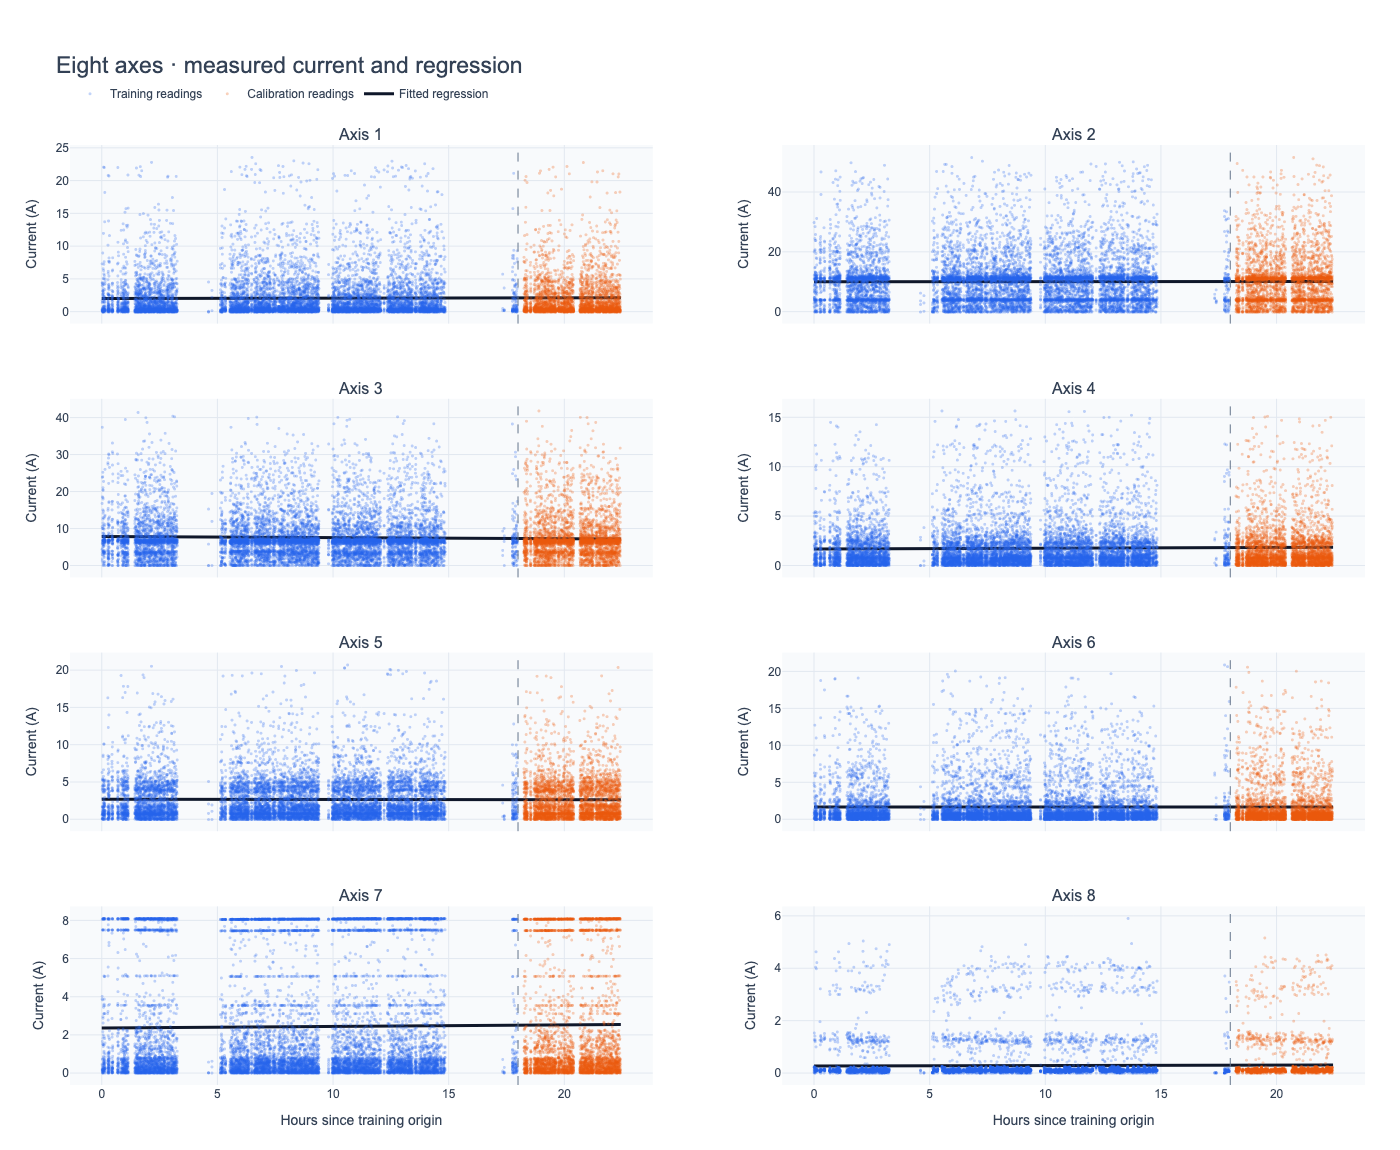

In [8]:
# WebGL scatter traces keep all readings interactive without downsampling.
regression_fig = make_subplots(
    rows=4, cols=2, shared_xaxes="all",
    subplot_titles=[axis.replace("_", " ").title() for axis in AXIS_COLUMNS],
    vertical_spacing=0.08, horizontal_spacing=0.10,
)

line_seconds = np.array([
    train["elapsed_seconds"].iloc[0],
    calibration["elapsed_seconds"].iloc[-1],
])
split_hour = calibration["elapsed_seconds"].iloc[0] / 3600

for index, axis in enumerate(AXIS_COLUMNS):
    row, col = divmod(index, 2)
    row, col = row + 1, col + 1
    for label, partition, color in [
        ("Training readings", train_active, CHART_COLORS["training"]),
        ("Calibration readings", calibration_active, CHART_COLORS["calibration"]),
    ]:
        regression_fig.add_trace(go.Scattergl(
            x=partition["elapsed_seconds"] / 3600, y=partition[axis],
            mode="markers", name=label, legendgroup=label,
            showlegend=index == 0,
            marker=dict(size=3, opacity=0.28, color=color),
            hovertemplate=(axis.replace("_", " ").title()
                           + "<br>Elapsed: %{x:.3f} h<br>Current: %{y:.3f} A<extra>"
                           + label + "</extra>"),
        ), row=row, col=col)

    line_current = (models[axis]["intercept_A"]
                    + models[axis]["slope_A_per_second"] * line_seconds)
    regression_fig.add_trace(go.Scatter(
        x=line_seconds / 3600, y=line_current, mode="lines",
        name="Fitted regression", legendgroup="regression", showlegend=index == 0,
        line=dict(color=CHART_COLORS["line"], width=3),
        hovertemplate="Elapsed: %{x:.3f} h<br>Prediction: %{y:.3f} A<extra>Regression</extra>",
    ), row=row, col=col)
    regression_fig.add_vline(
        x=split_hour, line_dash="dash", line_color="#64748b", line_width=1,
        row=row, col=col,
    )
    regression_fig.update_yaxes(title_text="Current (A)", row=row, col=col)

regression_fig.update_xaxes(title_text="Hours since training origin", row=4)
style_chart(regression_fig, "Eight axes · measured current and regression")
show_chart(regression_fig, "regression_lines", interactive=False)

## 9 · See how the residuals are distributed

**What happens next:** Group residuals into bins. Each bar shows how common a range of errors is. Training and calibration use the same bin edges for each axis so their shapes can be compared fairly.

**Why density instead of raw counts?** Training has more rows. Density adjusts for the number of readings and the bin width; the total bar area for each distribution is 1. A taller bar means that range is more concentrated, not necessarily that it contains more raw readings than the other partition.

- **Zero:** prediction and measurement agree.
- **Right of zero:** the measurement is above the model's line.
- **Left of zero:** the measurement is below the line.
- **A long right tail:** some readings are much higher than predicted; this alone does not prove a fault.

Hover over a bar to see its range, count, and share of that partition. Hide either group with the legend if the overlap is hard to read.

### Reading the percentile table

**p95** is a value at or below which about 95% of residuals fall; **p99** does the same for about 99%. These are calculated from the signed residuals of active readings. `calibration_max_A` is the largest signed residual in calibration.

### Counting outliers

Two common outlier rules are counted per axis, as a share of active readings:

- **IQR rule (Tukey):** above Q3 + 1.5 × IQR, where IQR is the spread of the middle half of training residuals.
- **3 SD rule:** more than three residual standard deviations above the line.

If calibration shows a much larger outlier share than training, later behaviour has drifted from what the model learned.

These values are starting evidence for **MinC** (Alert deviation) and **MaxC** (Error deviation), not final thresholds. An unusually high reading might be a normal operating spike.

> **Duration is still missing.** A histogram forgets the order of readings. Next we must examine consecutive exceedances and recording gaps before choosing **T**, the number of continuous seconds required. We cannot infer sustained faults or a false-alarm rate from this chart alone.

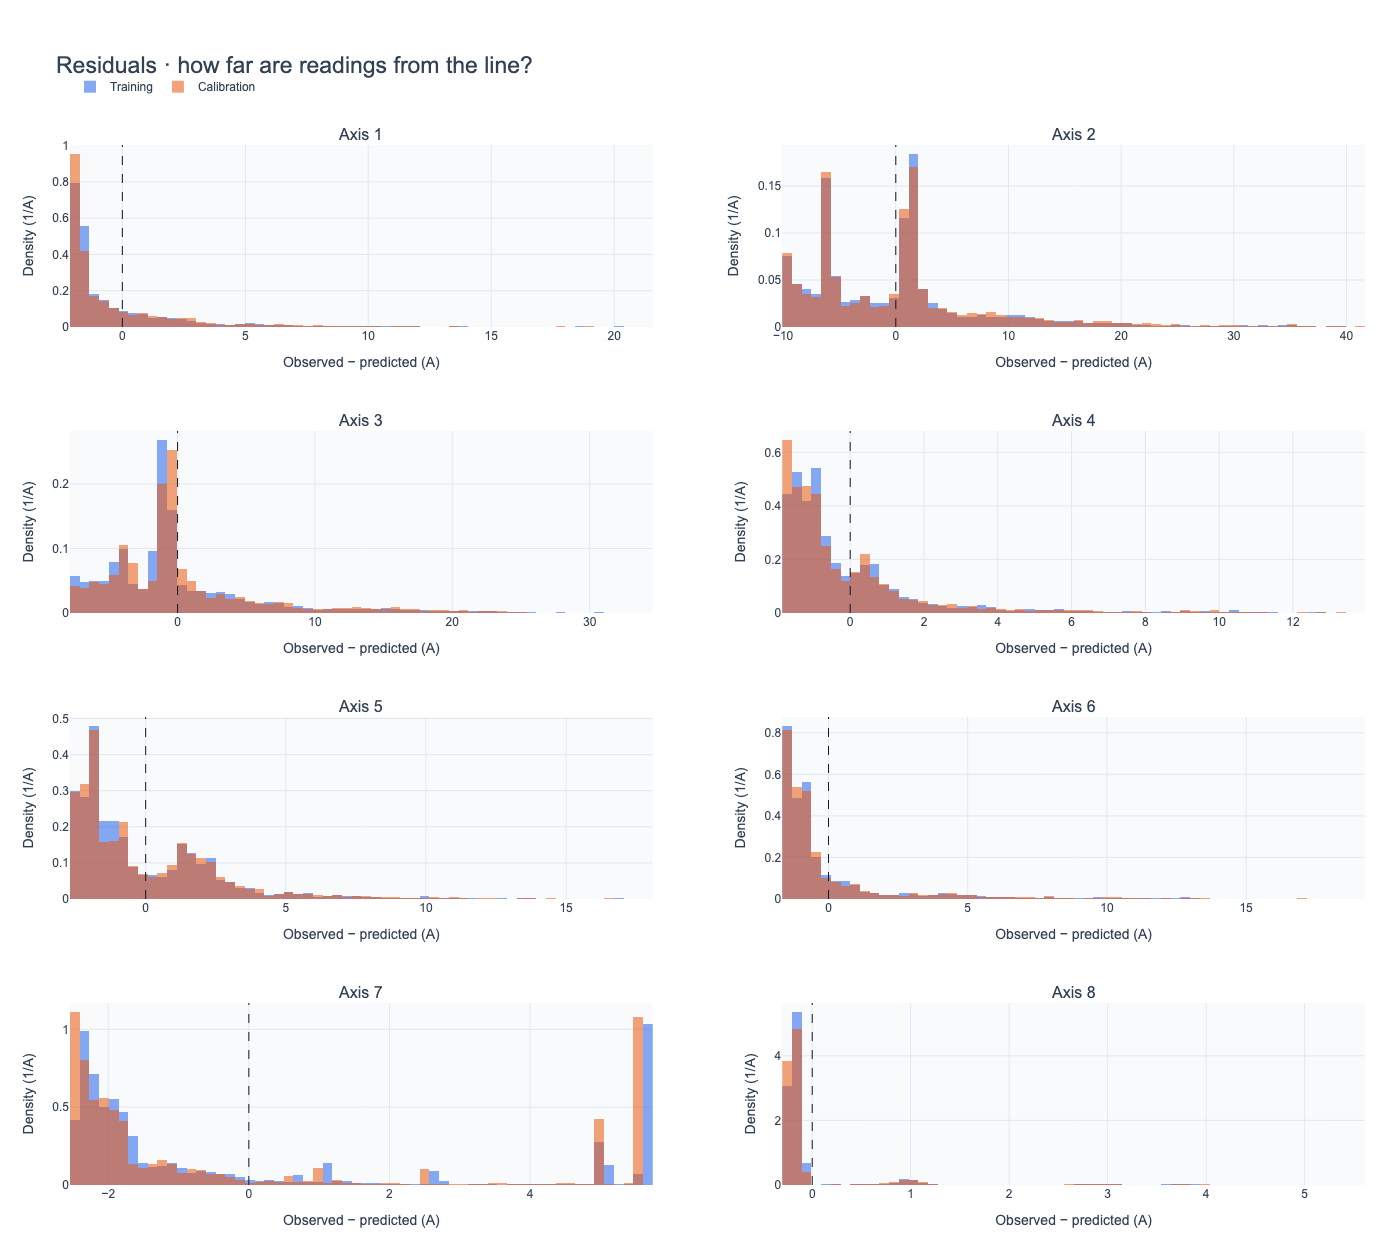

,train_std_A,train_p95_A,train_p99_A,calibration_p95_A,calibration_p99_A,calibration_max_A,IQR_fence_A,train_IQR_outliers_pct,calibration_IQR_outliers_pct,train_3sd_outliers_pct,calibration_3sd_outliers_pct
axis_1,3.299,6.637,14.337,6.126,11.916,20.708,3.755,9.653,8.237,2.621,1.990
axis_2,8.128,16.035,31.926,17.395,31.371,41.640,13.702,6.378,7.076,2.196,2.101
axis_3,6.001,13.549,22.214,14.194,22.669,34.594,8.732,8.366,8.900,2.375,2.570
axis_4,2.245,4.676,10.172,4.348,9.892,13.304,3.241,7.448,6.965,2.811,2.543
axis_5,2.789,5.208,10.788,5.365,10.669,17.804,6.388,3.624,3.676,1.959,2.045
axis_6,2.690,5.596,12.364,6.184,12.427,18.961,1.790,12.813,13.543,2.981,3.206
axis_7,3.052,5.647,5.719,5.552,5.565,5.583,6.331,0.000,0.000,0.000,0.000
axis_8,0.672,1.031,3.672,1.051,3.561,4.860,-0.056,11.328,10.614,3.227,3.123


In [9]:
# Calculate histogram bins in Python so hover labels can include exact counts.
residual_fig = make_subplots(
    rows=4, cols=2,
    subplot_titles=[axis.replace("_", " ").title() for axis in AXIS_COLUMNS],
    vertical_spacing=0.10, horizontal_spacing=0.10,
)

for index, axis in enumerate(AXIS_COLUMNS):
    row, col = divmod(index, 2)
    row, col = row + 1, col + 1
    combined = np.concatenate([
        train_active_residuals[axis].to_numpy(),
        calibration_active_residuals[axis].to_numpy(),
    ])
    edges = np.histogram_bin_edges(combined, bins=60)
    widths = np.diff(edges)
    centers = (edges[:-1] + edges[1:]) / 2

    for label, residuals, color in [
        ("Training", train_active_residuals, CHART_COLORS["training"]),
        ("Calibration", calibration_active_residuals, CHART_COLORS["calibration"]),
    ]:
        counts, _ = np.histogram(residuals[axis], bins=edges)
        shares = counts / len(residuals)
        density = shares / widths
        residual_fig.add_trace(go.Bar(
            x=centers, y=density, width=widths,
            name=label, legendgroup=label, showlegend=index == 0,
            marker=dict(color=color, line_width=0), opacity=0.55,
            customdata=np.column_stack([edges[:-1], edges[1:], counts, shares]),
            hovertemplate=("Range: %{customdata[0]:.2f} to %{customdata[1]:.2f} A"
                           "<br>Readings: %{customdata[2]:,.0f}"
                           "<br>Share: %{customdata[3]:.1%}"
                           "<br>Density: %{y:.3f}<extra>" + label + "</extra>"),
        ), row=row, col=col)
    residual_fig.add_vline(
        x=0, line_dash="dash", line_color=CHART_COLORS["line"], line_width=1,
        row=row, col=col,
    )
    residual_fig.update_xaxes(title_text="Observed − predicted (A)", row=row, col=col)
    residual_fig.update_yaxes(title_text="Density (1/A)", row=row, col=col)

style_chart(residual_fig, "Residuals · how far are readings from the line?", height=1250)
residual_fig.update_layout(barmode="overlay", bargap=0)
show_chart(residual_fig, "residual_distributions")

residual_std = train_active_residuals.std()
q1 = train_active_residuals.quantile(0.25)
q3 = train_active_residuals.quantile(0.75)
iqr_fence = q3 + 1.5 * (q3 - q1)

residual_summary = pd.DataFrame({
    "train_std_A": residual_std,
    "train_p95_A": train_active_residuals.quantile(0.95),
    "train_p99_A": train_active_residuals.quantile(0.99),
    "calibration_p95_A": calibration_active_residuals.quantile(0.95),
    "calibration_p99_A": calibration_active_residuals.quantile(0.99),
    "calibration_max_A": calibration_active_residuals.max(),
    "IQR_fence_A": iqr_fence,
    "train_IQR_outliers_pct": 100 * train_active_residuals.gt(iqr_fence).mean(),
    "calibration_IQR_outliers_pct": 100 * calibration_active_residuals.gt(iqr_fence).mean(),
    "train_3sd_outliers_pct": 100 * train_active_residuals.gt(3 * residual_std).mean(),
    "calibration_3sd_outliers_pct": 100 * calibration_active_residuals.gt(3 * residual_std).mean(),
})
display(residual_summary.round(3))

## 10 · Look for patterns in the residuals

A histogram shows *how big* the errors are, but not *when* they happen. Two more views:

1. **Residuals over time.** If the model were missing a trend (for example, a joint slowly drawing more current as it wears), residuals would drift upward across the hours. A flat band centred on zero means the straight line has captured the level, and what remains is the work cycle.
2. **Box plots on a common scale.** Each residual is divided by its axis's training residual standard deviation, so all eight joints share one axis. The box holds the middle half of readings; the points beyond the whiskers are the outliers counted above.

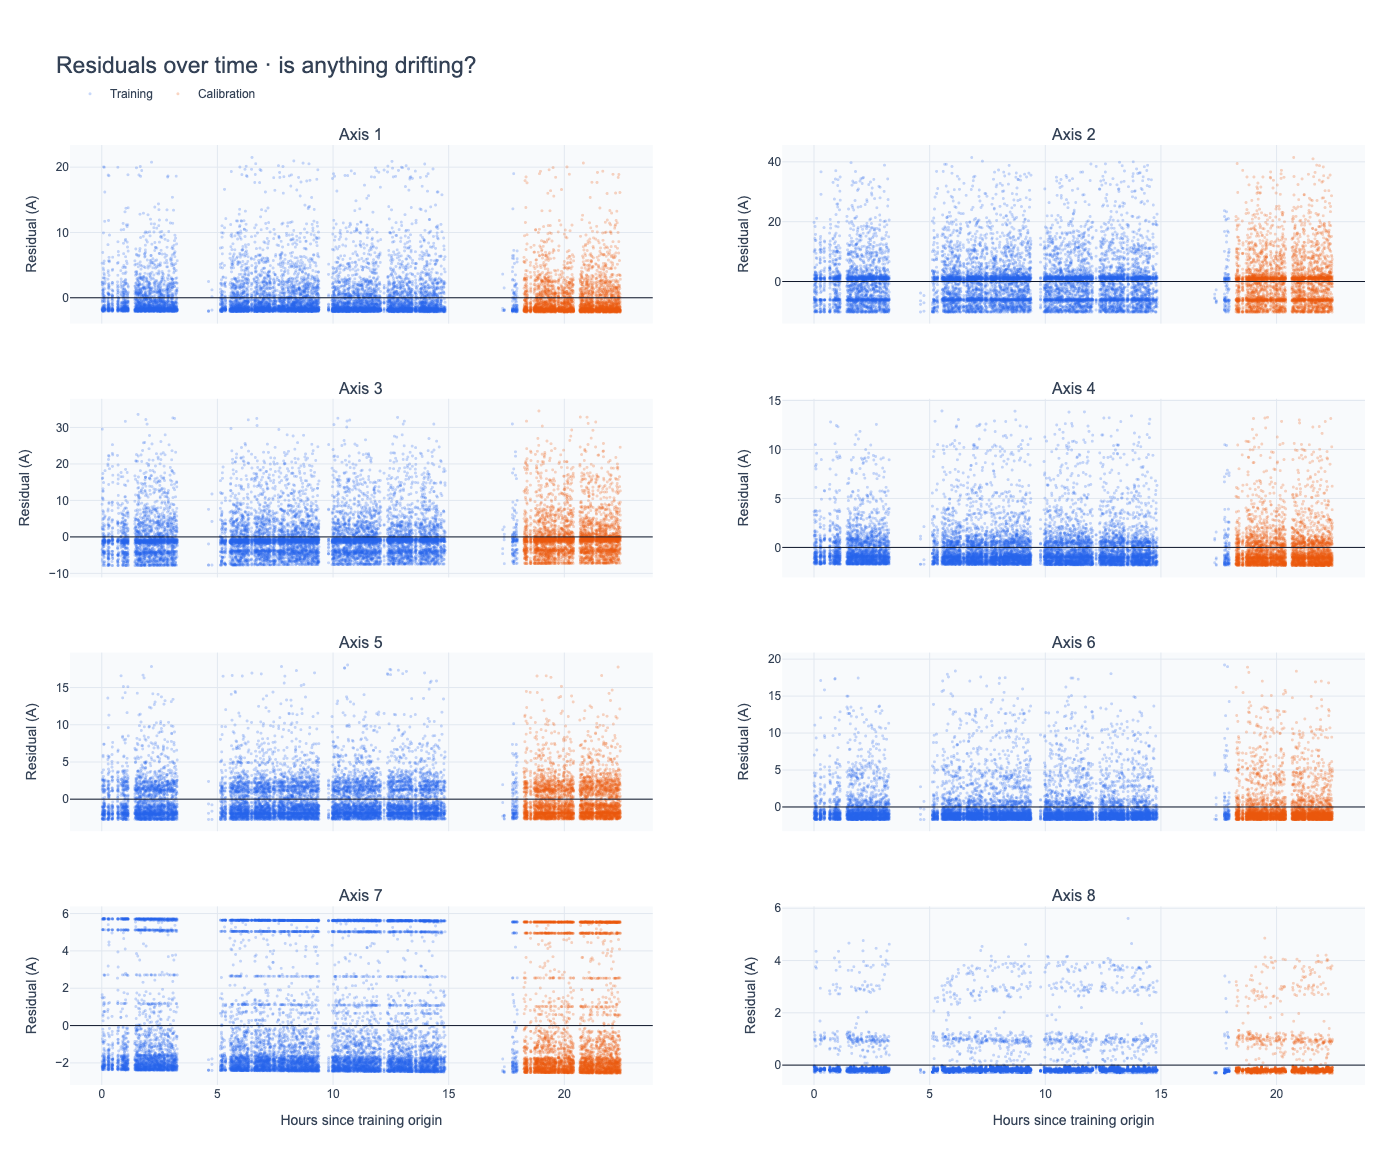

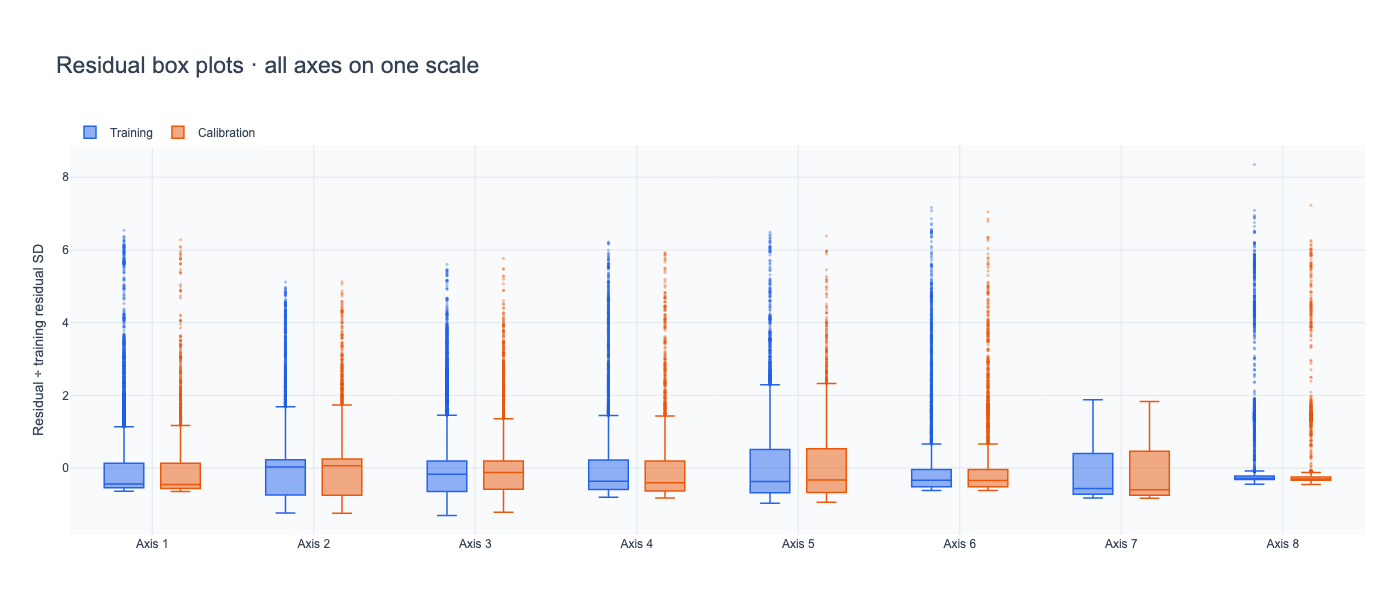

In [10]:
pattern_fig = make_subplots(
    rows=4, cols=2, shared_xaxes="all",
    subplot_titles=[axis.replace("_", " ").title() for axis in AXIS_COLUMNS],
    vertical_spacing=0.08, horizontal_spacing=0.10,
)

for index, axis in enumerate(AXIS_COLUMNS):
    row, col = divmod(index, 2)
    row, col = row + 1, col + 1

    for label, partition, residuals, color in [
        ("Training", train_active, train_active_residuals, CHART_COLORS["training"]),
        ("Calibration", calibration_active, calibration_active_residuals, CHART_COLORS["calibration"]),
    ]:
        pattern_fig.add_trace(go.Scattergl(
            x=partition["elapsed_seconds"] / 3600, y=residuals[axis],
            mode="markers", name=label, legendgroup=label,
            showlegend=index == 0,
            marker=dict(size=3, opacity=0.25, color=color),
            hovertemplate="Elapsed: %{x:.3f} h<br>Residual: %{y:.3f} A<extra>" + label + "</extra>",
        ), row=row, col=col)

    pattern_fig.add_hline(
        y=0, line_color=CHART_COLORS["line"], line_width=1, row=row, col=col,
    )
    pattern_fig.update_yaxes(title_text="Residual (A)", row=row, col=col)

pattern_fig.update_xaxes(title_text="Hours since training origin", row=4)
style_chart(pattern_fig, "Residuals over time · is anything drifting?")
show_chart(pattern_fig, "residuals_over_time", interactive=False)

box_fig = go.Figure()

for label, residuals, color in [
    ("Training", train_active_residuals, CHART_COLORS["training"]),
    ("Calibration", calibration_active_residuals, CHART_COLORS["calibration"]),
]:
    standardized = (residuals / residual_std).melt(
        var_name="axis", value_name="residual_sd"
    )
    box_fig.add_trace(go.Box(
        x=standardized["axis"].str.replace("axis_", "Axis "),
        y=standardized["residual_sd"],
        name=label, marker_color=color, boxpoints="outliers",
        marker=dict(size=3, opacity=0.4), line=dict(width=1.5),
    ))

box_fig.update_layout(boxmode="group")
box_fig.update_yaxes(title_text="Residual ÷ training residual SD")
style_chart(box_fig, "Residual box plots · all axes on one scale", height=600)
show_chart(box_fig, "residual_boxplots")

## 11 · Discover candidate thresholds

A large prediction error does not automatically mean a fault. A robot may briefly draw extra current while doing normal work.

We therefore ask two questions:

1. **How high?** How far above the regression line is the reading?
2. **How long?** Does that extra current continue across several readings?

Training residual percentiles of active readings propose deviation levels for each axis. The 95th percentile, for example, is a deviation that only 5% of working readings reach even for an instant. We list several levels, from p80 to p99.5, because the next sections test which combination of level and duration stays quiet on healthy data.

### Why separate thresholds for each axis?

An extra 2 A is a large change for Axis 8, which normally draws about 0.3 A while working, but an ordinary change for Axis 2, which averages about 10 A. Each axis therefore gets its own deviation levels.

### A limitation of our models

Training R² is about zero for every axis: elapsed time explains almost none of the cycle-to-cycle variation. That is expected. Over 22 hours a healthy robot's average load does not trend, so the line is essentially each joint's typical working current, and the near-zero slopes say there is **no measurable drift** in this window. The residuals are therefore mostly the work cycle itself, which is why duration matters so much. Without confirmed fault labels, we cannot calculate fault accuracy or a false-alarm rate against real failures.

In [11]:
# These percentiles propose thresholds; they do not select the final rules.
CANDIDATE_QUANTILES = [0.80, 0.85, 0.90, 0.95, 0.975, 0.99, 0.995]

threshold_candidates = train_active_residuals.quantile(
    CANDIDATE_QUANTILES
).T

threshold_candidates.columns = [
    f"p{quantile * 100:g}".replace(".", "_")
    for quantile in CANDIDATE_QUANTILES
]
threshold_candidates.index.name = "axis"

display(threshold_candidates.round(3))

,p80,p85,p90,p95,p97_5,p99,p99_5
axis,,,,,,,
axis_1,1.119,2.098,3.582,6.637,10.005,14.337,18.764
axis_2,3.074,5.917,10.184,16.035,22.097,31.926,34.974
axis_3,2.729,4.353,7.289,13.549,17.713,22.214,24.794
axis_4,0.762,1.246,2.193,4.676,7.429,10.172,11.222
axis_5,1.813,2.315,3.028,5.208,7.479,10.788,13.511
axis_6,0.435,1.103,2.987,5.596,9.048,12.364,13.462
axis_7,5.022,5.555,5.630,5.647,5.697,5.719,5.725
axis_8,-0.132,-0.089,0.141,1.031,2.854,3.672,3.830


## 12 · Measure continuous exceedances

An exceedance occurs when a residual is at least as large as a threshold.
A run is a sequence of consecutive exceedances.

Example: readings exceed the threshold at 0, 2, 4, and 6 seconds.
Their observed duration is **6 seconds**, not 8 seconds. We measure from
the first qualifying timestamp to the last.

A run ends when:

- a reading falls below the threshold, or
- the gap between readings exceeds our allowed sampling gap.

We initially allow gaps up to three times the median training interval.
This is an explicit working assumption that tolerates sampling jitter;
it is not proof of what happened between observations.

We assume continuity between qualifying readings only within that gap limit.
A run touching the beginning or end of calibration may extend beyond the
available data, so its measured duration is only the observed portion.

In [12]:
training_gaps = (
    train["reading_time"].diff().dt.total_seconds().dropna()
)

MEDIAN_INTERVAL_SECONDS = float(training_gaps.median())
MAX_GAP_SECONDS = 3 * MEDIAN_INTERVAL_SECONDS

if not np.isfinite(MAX_GAP_SECONDS) or MAX_GAP_SECONDS <= 0:
    raise ValueError("Cannot establish a valid sampling interval.")

print(f"Median training interval: {MEDIAN_INTERVAL_SECONDS:.3f} s")
print(f"Initial allowed gap:      {MAX_GAP_SECONDS:.3f} s")
print(
    "Calibration gaps above this limit:",
    calibration["reading_time"]
    .diff()
    .dt.total_seconds()
    .gt(MAX_GAP_SECONDS)
    .sum(),
)


def find_exceedance_runs(timestamps, residuals, threshold_A):
    """Summarize observed runs at or above one positive threshold."""
    if not np.isfinite(threshold_A) or threshold_A <= 0:
        raise ValueError("The deviation threshold must be positive.")

    if len(timestamps) != len(residuals):
        raise ValueError("Timestamps and residuals must have equal lengths.")

    readings = pd.DataFrame({
        "time": pd.to_datetime(
            list(timestamps), utc=True, errors="raise"
        ),
        "residual_A": np.asarray(residuals, dtype=float),
    })

    if readings.empty:
        raise ValueError("No readings supplied.")

    if readings["time"].isna().any():
        raise ValueError("Missing timestamps.")

    if not np.isfinite(readings["residual_A"]).all():
        raise ValueError("Invalid residual values.")

    gaps = readings["time"].diff().dt.total_seconds()

    if gaps.dropna().le(0).any():
        raise ValueError("Timestamps must be unique and increasing.")

    above = readings["residual_A"].ge(threshold_A)

    # Begin again after a below-threshold reading or a recording gap.
    new_run = above & (
        ~above.shift(fill_value=False)
        | gaps.gt(MAX_GAP_SECONDS)
    )

    readings["run_id"] = new_run.cumsum()

    runs = (
        readings.loc[above]
        .groupby("run_id")
        .agg(
            start=("time", "min"),
            end=("time", "max"),
            sample_count=("time", "size"),
            peak_residual_A=("residual_A", "max"),
        )
        .reset_index(drop=True)
    )

    runs["duration_seconds"] = (
        runs["end"] - runs["start"]
    ).dt.total_seconds()

    return runs

Median training interval: 1.891 s
Initial allowed gap:      5.673 s
Calibration gaps above this limit: 136


### How long do large deviations last in healthy data?

This is the key evidence for **T**. For every axis we find each run of consecutive readings above the training p95 and count how many readings it lasts. Then we ask the reverse question: **what is the largest deviation an axis holds for four consecutive readings** (about 5.7 s at the 1.9 s sampling interval)?

If healthy spikes almost always last one or two readings, a duration rule that needs four readings will ignore normal work but still catch a joint that stays overloaded.

,runs_above_p95,one_reading_pct,two_readings_pct,three_plus_readings,longest_run_seconds,p95_A,held_4_readings_train_A,held_4_readings_calibration_A
axis,,,,,,,,
axis_1,520,98.27,1.73,0,2.04,6.64,0.43,0.30
axis_2,497,93.56,6.44,0,2.00,16.04,5.98,3.95
axis_3,493,93.10,6.49,2,3.82,13.55,5.42,4.59
axis_4,529,100.00,0.00,0,0.00,4.68,0.67,1.15
axis_5,487,91.38,8.62,0,2.02,5.21,2.14,2.24
axis_6,483,90.48,9.52,0,5.59,5.60,0.59,0.25
axis_7,476,90.13,8.61,6,4.00,5.65,5.62,4.96
axis_8,493,92.70,7.30,0,2.01,1.03,-0.04,-0.06


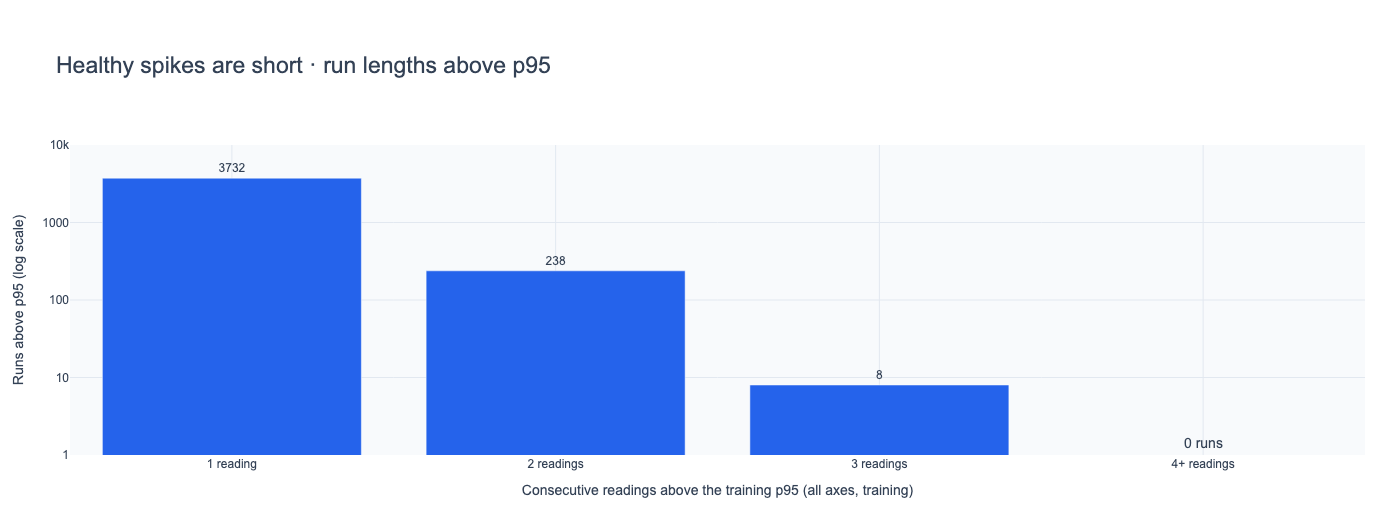

In [13]:
SUSTAINED_READINGS = 4

duration_rows = []
run_lengths = []

for axis in AXIS_COLUMNS:
    p95 = threshold_candidates.loc[axis, "p95"]
    runs = find_exceedance_runs(train["reading_time"], train_residuals[axis], p95)
    run_lengths.append(runs["sample_count"])

    duration_rows.append({
        "axis": axis,
        "runs_above_p95": len(runs),
        "one_reading_pct": 100 * runs["sample_count"].eq(1).mean(),
        "two_readings_pct": 100 * runs["sample_count"].eq(2).mean(),
        "three_plus_readings": int(runs["sample_count"].ge(3).sum()),
        "longest_run_seconds": runs["duration_seconds"].max(),
    })

run_duration_summary = pd.DataFrame(duration_rows).set_index("axis")


def largest_sustained_deviation(readings, residuals, readings_needed):
    """Largest residual held for N consecutive readings without a recording gap."""
    segment = (
        readings["reading_time"].diff().dt.total_seconds()
        .gt(MAX_GAP_SECONDS).cumsum().to_numpy()
    )
    return residuals.groupby(segment).transform(
        lambda values: values.rolling(readings_needed).min()
    ).max()


run_duration_summary["p95_A"] = threshold_candidates["p95"]
run_duration_summary["held_4_readings_train_A"] = [
    largest_sustained_deviation(train, train_residuals[axis], SUSTAINED_READINGS)
    for axis in AXIS_COLUMNS
]
run_duration_summary["held_4_readings_calibration_A"] = [
    largest_sustained_deviation(calibration, calibration_residuals[axis], SUSTAINED_READINGS)
    for axis in AXIS_COLUMNS
]

display(run_duration_summary.round(2))

all_lengths = pd.concat(run_lengths).clip(upper=4)
length_counts = all_lengths.value_counts().reindex([1, 2, 3, 4], fill_value=0)

run_length_fig = go.Figure(go.Bar(
    x=["1 reading", "2 readings", "3 readings", "4+ readings"],
    y=length_counts.to_numpy(),
    marker_color=CHART_COLORS["training"],
    text=length_counts.to_numpy(), textposition="outside",
    hovertemplate="%{x}: %{y} runs<extra></extra>",
))
run_length_fig.update_yaxes(
    type="log", dtick=1, range=[0, 4], title_text="Runs above p95 (log scale)",
)

# A log scale cannot draw zero, so label empty categories explicitly.
for label, count in zip(["1 reading", "2 readings", "3 readings", "4+ readings"], length_counts):
    if count == 0:
        run_length_fig.add_annotation(
            x=label, y=0.15, text="0 runs", showarrow=False,
            font=dict(size=14, color="#334155"),
        )
run_length_fig.update_xaxes(title_text="Consecutive readings above the training p95 (all axes, training)")
style_chart(run_length_fig, "Healthy spikes are short · run lengths above p95", height=520)
show_chart(run_length_fig, "run_lengths")

### Test thresholds and durations together

Every candidate level (p80 to p99.5) is combined with every candidate duration (2 to 10 s), and we count the qualifying runs in the **calibration** period. Where the curves rise, alerts appear. We want the combination that stays quiet on healthy readings yet would still fire on a sustained overload.

In [14]:
# Initial durations to investigate, not final choices.
DURATION_CANDIDATES = [2, 4, 5, 6, 10]

comparison_rows = []

for axis in AXIS_COLUMNS:
    residuals = calibration_residuals[axis]

    for candidate_name, threshold_A in (
        threshold_candidates.loc[axis].items()
    ):
        # A nonpositive percentile cannot represent an above-line limit.
        if not np.isfinite(threshold_A) or threshold_A <= 0:
            continue

        runs = find_exceedance_runs(
            calibration["reading_time"],
            residuals,
            threshold_A,
        )

        longest_run = (
            float(runs["duration_seconds"].max())
            if not runs.empty else 0.0
        )

        for duration in DURATION_CANDIDATES:
            sustained = runs.loc[
                runs["duration_seconds"].ge(duration)
            ]

            comparison_rows.append({
                "axis": axis,
                "candidate": candidate_name,
                "threshold_A": threshold_A,
                "T_seconds": duration,
                "exceeding_readings_pct": (
                    100 * calibration_active_residuals[axis].ge(threshold_A).mean()
                ),
                "all_runs": len(runs),
                "sustained_runs": len(sustained),
                "longest_run_seconds": longest_run,
            })

threshold_comparison = pd.DataFrame(comparison_rows)

display(threshold_comparison.round(3))

,axis,candidate,threshold_A,T_seconds,exceeding_readings_pct,all_runs,sustained_runs,longest_run_seconds
0,axis_1,p80,1.119,2,19.679,621,17,7.378
1,axis_1,p80,1.119,4,19.679,621,1,7.378
2,axis_1,p80,1.119,5,19.679,621,1,7.378
3,axis_1,p80,1.119,6,19.679,621,1,7.378
4,axis_1,p80,1.119,10,19.679,621,0,7.378
...,...,...,...,...,...,...,...,...
265,axis_8,p99_5,3.830,2,0.553,20,0,0.000
266,axis_8,p99_5,3.830,4,0.553,20,0,0.000
267,axis_8,p99_5,3.830,5,0.553,20,0,0.000
268,axis_8,p99_5,3.830,6,0.553,20,0,0.000


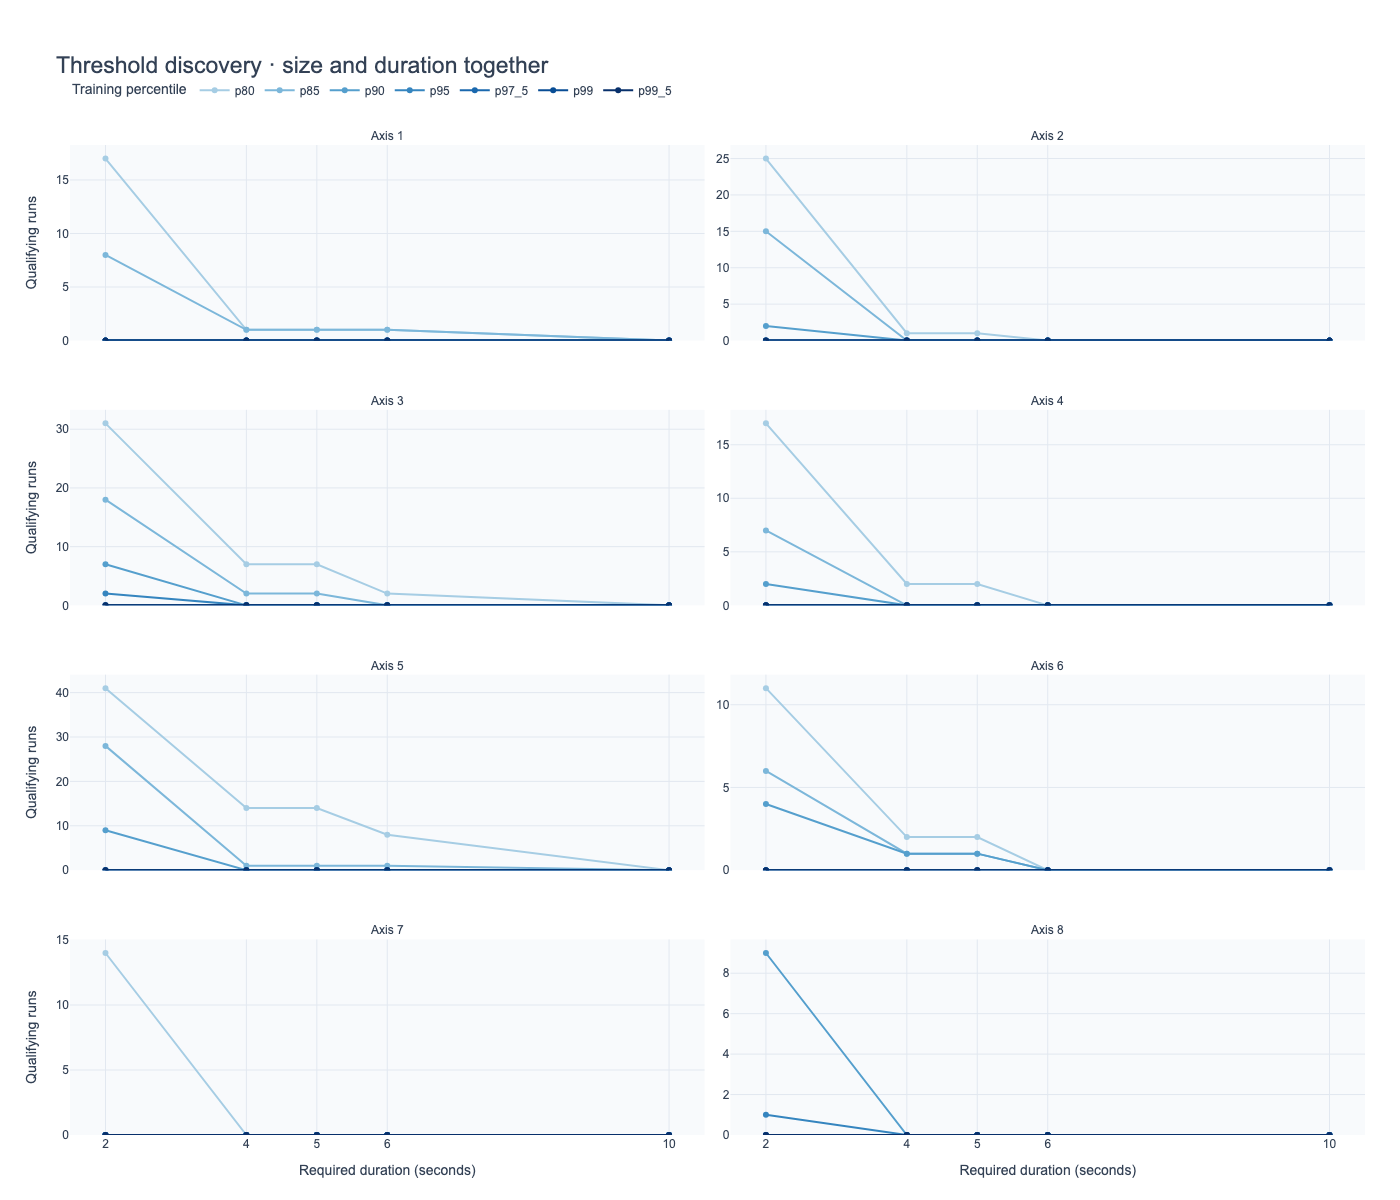

In [15]:
import plotly.express as px

threshold_fig = px.line(
    threshold_comparison,
    x="T_seconds",
    y="sustained_runs",
    color="candidate",
    facet_col="axis",
    facet_col_wrap=2,
    markers=True,
    # Percentiles are ordered, so one hue runs light (p80) to dark (p99.5).
    color_discrete_sequence=px.colors.sample_colorscale(
        "Blues", list(np.linspace(0.35, 1.0, len(CANDIDATE_QUANTILES)))
    ),
    category_orders={
        "axis": AXIS_COLUMNS,
        "candidate": list(threshold_candidates.columns),
    },
    custom_data=["threshold_A", "longest_run_seconds"],
    labels={
        "T_seconds": "Required duration (seconds)",
        "sustained_runs": "Qualifying runs",
        "candidate": "Training percentile",
    },
)

threshold_fig.update_traces(
    hovertemplate=(
        "Required duration: %{x} s"
        "<br>Qualifying runs: %{y}"
        "<br>Deviation threshold: %{customdata[0]:.3f} A"
        "<br>Longest observed run: %{customdata[1]:.2f} s"
        "<extra>%{fullData.name}</extra>"
    )
)

threshold_fig.for_each_annotation(
    lambda annotation: annotation.update(
        text=annotation.text.replace("axis=axis_", "Axis ")
    )
)

threshold_fig.update_xaxes(tickvals=DURATION_CANDIDATES)
threshold_fig.update_yaxes(matches=None, rangemode="tozero", showticklabels=True)

style_chart(
    threshold_fig,
    "Threshold discovery · size and duration together",
    height=1200,
)
show_chart(threshold_fig, "threshold_discovery")

## 13 · Choose the Alert and Error rules

| Setting | Choice | Evidence |
|---|---|---|
| **MinC** (Alert) | Training p95 of active residuals, per axis | The lowest candidate level at which the healthy calibration period produces **no** sustained run at T = 5 s (grid above). Only 5% of working readings reach it even for one sample. |
| **MaxC** (Error) | Training p99, but at least MinC + 1 residual SD | 1% of working readings reach p99 for an instant. The floor guarantees an Error is materially worse than an Alert. It only changes Axis 7 (below). |
| **T** | 5 s | Of 3,978 training runs above p95 (all axes), 93.8% last a single reading and only 8 reach three readings. T = 5 s normally needs four consecutive readings, longer than any healthy spike, yet still far quicker than any maintenance response. |

### Why these values, and not lower ones?

Sustained runs in the healthy calibration period, summed over all axes:

| Level / T | 2 s | 4 s | **5 s** | 6 s | 10 s |
|---|---|---|---|---|---|
| p80 | 156 | 27 | 27 | 11 | 0 |
| p85 | 82 | 5 | 5 | 2 | 0 |
| p90 | 33 | 1 | 1 | 0 | 0 |
| **p95** | 3 | 0 | **0** | 0 | 0 |
| p99 | 0 | 0 | 0 | 0 | 0 |

Lower levels fire on ordinary work cycles (at p80, mostly Axes 5 and 3), and at T = 2 s even p95 fires. At **p95 with T = 5 s**, healthy calibration data produces no events, and the 18 hours of training data produce two Alerts, both on Axis 6 (table below). Both are two-reading runs bridged by a 5.5 s sampling gap, just inside the 5.7 s gap allowance, rather than a sustained load. The largest deviation any axis holds for four consecutive readings (`held_4_readings_*`) is below its MinC on every axis: far below on Axes 1–6 and 8, and 0.03 A below on Axis 7, which is pinned at its current ceiling.

Above p95 no candidate produces any sustained run, so the data cannot separate p97.5 from p99 for MaxC. We choose p99 on severity grounds: a deviation that only 1 in 100 working readings reaches even momentarily.

This is what a predictive-maintenance rule should do on a robot with no known fault: stay quiet. Lowering the thresholds until healthy data produces alarms would teach the maintenance team to ignore them (alarm fatigue).

### Why Axis 7 needs the MaxC floor

Axis 7 never draws more than **8.11 A**: 164 training readings sit exactly at 8.108 A and 1,598 at 8.0 A or more. The axis looks current-limited, so all its upper percentiles (p90 to p99.5) collapse onto the same plateau (5.6–5.7 A above the line). Taking p99 would make Alert and Error almost identical. The floor puts its MaxC at MinC + 1 SD, which in absolute terms means drawing more than the joint has ever drawn. That is a sensible meaning for "Error".

### Predictive-maintenance context

- Axes 2 and 3 carry the heaviest loads (mean working current around 10 A and 8 A), so their thresholds are widest in amps but equivalent in statistical terms.
- A wearing torque tube or a binding joint shows up as a joint that keeps drawing more current than its cycle normally needs. That is a *sustained* deviation, which is exactly what T filters for.
- An Alert says "inspect at the next planned stop". An Error says "stop and check now": the deviation is beyond 99% of healthy behaviour, held for 5 s.

### When both rules qualify

Alert and Error conditions have separate timers. An Error requires the residual to remain above MaxC for the full T seconds; time spent only above MinC does not count toward that timer. Both records are logged; a live display should show Error as the higher severity.

These are experimental monitoring rules, not verified equipment limits. We do not know the true fault labels, sensor accuracy, or required maintenance response time.

In [16]:
selected_thresholds = pd.DataFrame({
    "MinC_A": threshold_candidates["p95"],
    "p99_A": threshold_candidates["p99"],
    "MinC_plus_1sd_A": threshold_candidates["p95"] + residual_std,
})

# An Error must be materially larger than an Alert.
selected_thresholds["MaxC_A"] = selected_thresholds[
    ["p99_A", "MinC_plus_1sd_A"]
].max(axis=1)

selected_thresholds["MaxC_rule"] = np.where(
    selected_thresholds["p99_A"] >= selected_thresholds["MinC_plus_1sd_A"],
    "p99",
    "MinC + 1 SD",
)

selected_thresholds["T_seconds"] = 5.0
selected_thresholds["max_gap_seconds"] = MAX_GAP_SECONDS

if not (
    (selected_thresholds["MinC_A"] > 0)
    & (
        selected_thresholds["MaxC_A"]
        > selected_thresholds["MinC_A"]
    )
).all():
    raise ValueError("Every axis must satisfy 0 < MinC < MaxC.")

print(f"Axis 7 maximum training current: {train['axis_7'].max():.2f} A")
display(selected_thresholds.round(3))

Axis 7 maximum training current: 8.11 A


,MinC_A,p99_A,MinC_plus_1sd_A,MaxC_A,MaxC_rule,T_seconds,max_gap_seconds
axis,,,,,,,
axis_1,6.637,14.337,9.936,14.337,p99,5.0,5.673
axis_2,16.035,31.926,24.163,31.926,p99,5.0,5.673
axis_3,13.549,22.214,19.550,22.214,p99,5.0,5.673
axis_4,4.676,10.172,6.921,10.172,p99,5.0,5.673
axis_5,5.208,10.788,7.997,10.788,p99,5.0,5.673
axis_6,5.596,12.364,8.286,12.364,p99,5.0,5.673
axis_7,5.647,5.719,8.699,8.699,MinC + 1 SD,5.0,5.673
axis_8,1.031,3.672,1.703,3.672,p99,5.0,5.673


In [17]:
# The existing run detector reads MAX_GAP_SECONDS.
# Restore it after this comparison, even if an error occurs.
original_gap_limit = MAX_GAP_SECONDS
gap_sensitivity_rows = []

try:
    for multiplier in [2, 3, 4]:
        MAX_GAP_SECONDS = multiplier * MEDIAN_INTERVAL_SECONDS

        for axis in AXIS_COLUMNS:
            settings = selected_thresholds.loc[axis]

            for level, threshold_column in [
                ("Alert", "MinC_A"),
                ("Error", "MaxC_A"),
            ]:
                runs = find_exceedance_runs(
                    calibration["reading_time"],
                    calibration_residuals[axis],
                    settings[threshold_column],
                )

                gap_sensitivity_rows.append({
                    "gap_multiplier": multiplier,
                    "allowed_gap_seconds": MAX_GAP_SECONDS,
                    "axis": axis,
                    "level": level,
                    "qualifying_runs": int(
                        runs["duration_seconds"]
                        .ge(settings["T_seconds"])
                        .sum()
                    ),
                })
finally:
    MAX_GAP_SECONDS = original_gap_limit

gap_sensitivity = pd.DataFrame(gap_sensitivity_rows)

display(
    gap_sensitivity.groupby(
        ["gap_multiplier", "allowed_gap_seconds", "level"]
    )["qualifying_runs"]
    .sum()
    .unstack("level")
)

,level,Alert,Error
gap_multiplier,allowed_gap_seconds,,
2,3.782,0,0
3,5.673,0,0
4,7.564,0,0


In [18]:
def build_threshold_events(readings, residuals, thresholds):
    """Log qualifying Alert/Error runs separately for each axis."""
    if not readings.index.equals(residuals.index):
        raise ValueError("Readings and residuals must have matching indexes.")

    event_rows = []

    for axis in AXIS_COLUMNS:
        settings = thresholds.loc[axis]
        required_duration = float(settings["T_seconds"])

        if not np.isclose(
            settings["max_gap_seconds"], MAX_GAP_SECONDS
        ):
            raise ValueError("Configured gap differs from the detector gap.")

        for level, threshold_column in [
            ("Alert", "MinC_A"),
            ("Error", "MaxC_A"),
        ]:
            threshold_A = float(settings[threshold_column])

            runs = find_exceedance_runs(
                readings["reading_time"],
                residuals[axis],
                threshold_A,
            )

            qualifying = runs.loc[
                runs["duration_seconds"].ge(required_duration)
            ]

            for run in qualifying.itertuples(index=False):
                run_times = readings.loc[
                    readings["reading_time"].between(
                        run.start, run.end
                    ),
                    "reading_time",
                ]

                elapsed = (
                    run_times - run.start
                ).dt.total_seconds()

                # Trigger at the first actual observation confirming T.
                triggered_at = run_times.loc[
                    elapsed.ge(required_duration)
                ].iloc[0]

                event_rows.append({
                    "axis": axis,
                    "level": level,
                    "threshold_A": threshold_A,
                    "required_duration_seconds": required_duration,
                    "start": run.start,
                    "triggered_at": triggered_at,
                    "last_exceedance": run.end,
                    "observed_duration_seconds": run.duration_seconds,
                    "sample_count": run.sample_count,
                    "peak_residual_A": run.peak_residual_A,
                })

    columns = [
        "axis", "level", "threshold_A",
        "required_duration_seconds",
        "start", "triggered_at", "last_exceedance",
        "observed_duration_seconds", "sample_count",
        "peak_residual_A",
    ]

    return (
        pd.DataFrame(event_rows, columns=columns)
        .sort_values(["triggered_at", "axis", "level"])
        .reset_index(drop=True)
    )


training_events = build_threshold_events(
    train,
    train_residuals,
    selected_thresholds,
)

calibration_events = build_threshold_events(
    calibration,
    calibration_residuals,
    selected_thresholds,
)

# How often do the chosen rules fire on healthy historical data?
healthy_event_counts = pd.concat(
    {
        name: events.groupby(["axis", "level"]).size().unstack(fill_value=0)
        .reindex(index=AXIS_COLUMNS, columns=["Alert", "Error"], fill_value=0)
        for name, events in [
            ("training", training_events),
            ("calibration", calibration_events),
        ]
    },
    axis=1,
)

display(healthy_event_counts)
display(pd.concat([training_events, calibration_events]))

training       calibration      
level     Alert Error       Alert Error
axis                                   
axis_1        0     0           0     0
axis_2        0     0           0     0
axis_3        0     0           0     0
axis_4        0     0           0     0
axis_5        0     0           0     0
axis_6        2     0           0     0
axis_7        0     0           0     0
axis_8        0     0           0     0

,axis,level,threshold_A,required_duration_seconds,start,triggered_at,last_exceedance,observed_duration_seconds,sample_count,peak_residual_A
0,axis_6,Alert,5.595854,5.0,2022-10-17 20:35:07.233000+00:00,2022-10-17 20:35:12.716000+00:00,2022-10-17 20:35:12.716000+00:00,5.483,2,17.544856
1,axis_6,Alert,5.595854,5.0,2022-10-17 23:30:46.910000+00:00,2022-10-17 23:30:52.502000+00:00,2022-10-17 23:30:52.502000+00:00,5.592,2,17.492265


### The chosen rules on the historical regression chart

The same eight regression charts as Section 8, now with each axis's **Alert boundary** (line + MinC, dashed amber) and **Error boundary** (line + MaxC, dotted red). Every Alert or Error the rules raise on the real historical readings is marked and labelled with its duration.

Only two events appear in 22.5 hours, both Alerts on Axis 6 in the training period. Each is two readings bridged by a 5.5 s sampling gap, which is a borderline case rather than a sustained overload. Most readings that rise above the amber line fall back within one reading, which is why the duration rule T keeps them quiet.

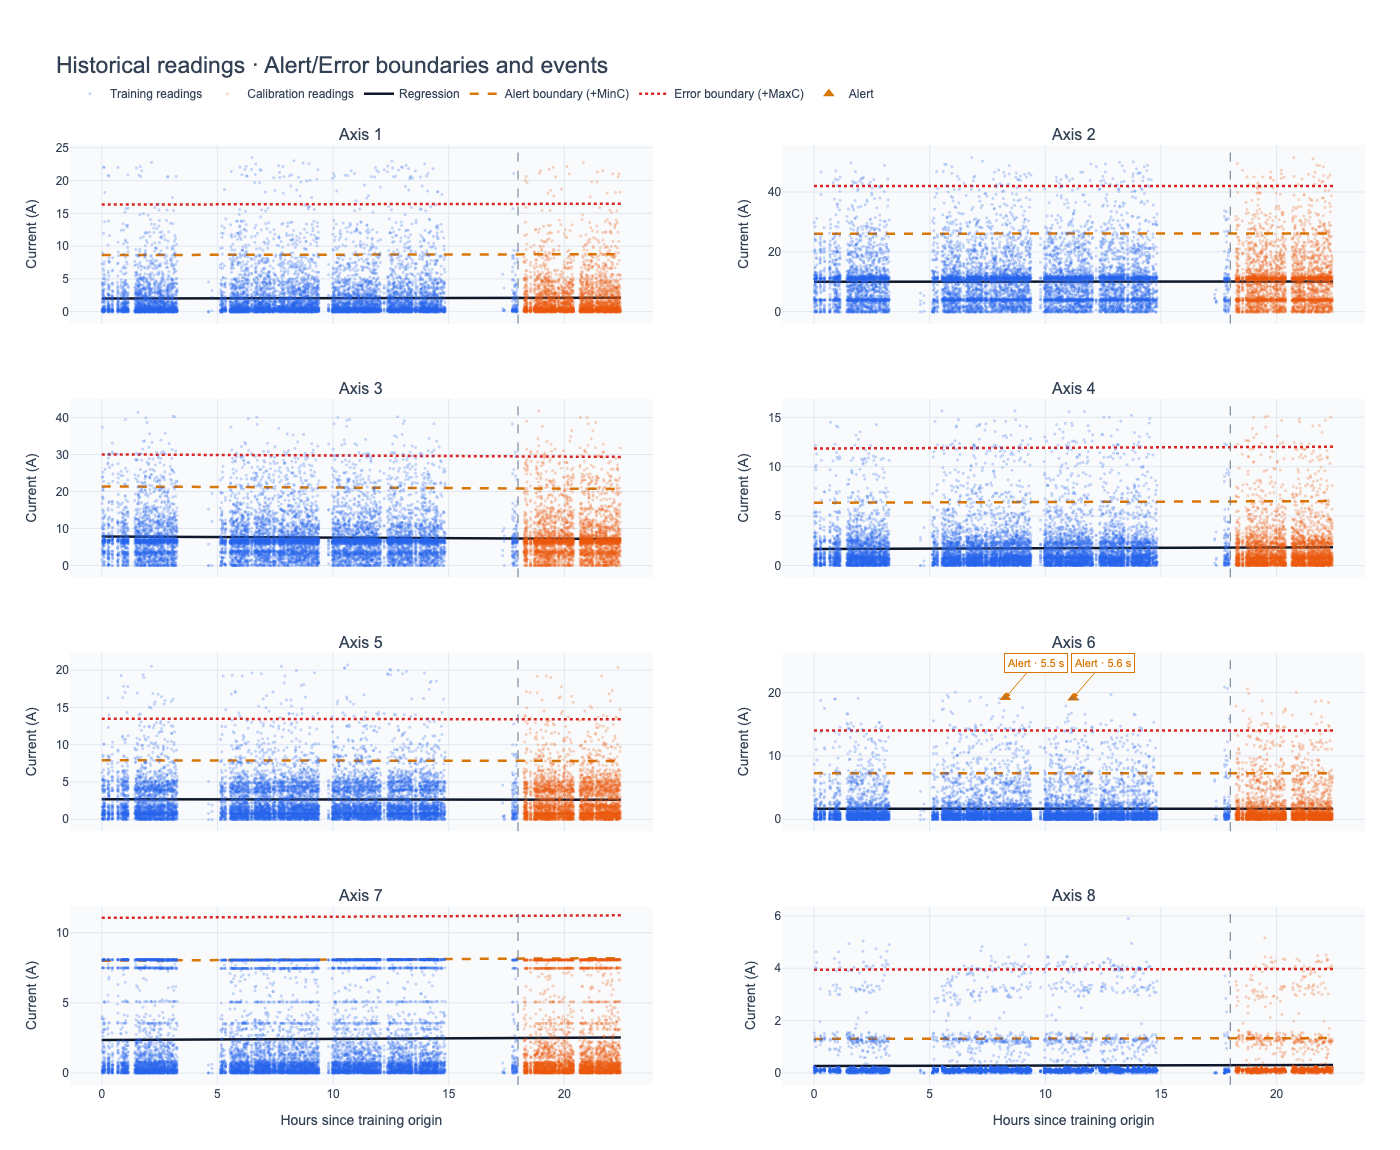

Historical events plotted: 2


In [19]:
historical_events = pd.concat(
    [training_events, calibration_events], ignore_index=True,
)

# Concatenating with an empty event table loses the datetime type.
historical_events["triggered_at"] = pd.to_datetime(
    historical_events["triggered_at"], utc=True
)
current_lookup = historical.set_index("reading_time")[AXIS_COLUMNS]

history_fig = make_subplots(
    rows=4, cols=2, shared_xaxes="all",
    subplot_titles=[axis.replace("_", " ").title() for axis in AXIS_COLUMNS],
    vertical_spacing=0.08, horizontal_spacing=0.10,
)
shown_in_legend = set()

for index, axis in enumerate(AXIS_COLUMNS):
    row, col = divmod(index, 2)
    row, col = row + 1, col + 1
    settings = selected_thresholds.loc[axis]

    for label, partition, color in [
        ("Training readings", train_active, CHART_COLORS["training"]),
        ("Calibration readings", calibration_active, CHART_COLORS["calibration"]),
    ]:
        history_fig.add_trace(go.Scattergl(
            x=partition["elapsed_seconds"] / 3600, y=partition[axis],
            mode="markers", name=label, legendgroup=label,
            showlegend=index == 0,
            marker=dict(size=3, opacity=0.25, color=color),
            hoverinfo="skip",
        ), row=row, col=col)

    line_current = (models[axis]["intercept_A"]
                    + models[axis]["slope_A_per_second"] * line_seconds)

    for name, offset, color, dash in [
        ("Regression", 0.0, CHART_COLORS["line"], "solid"),
        ("Alert boundary (+MinC)", settings["MinC_A"], EVENT_COLORS["Alert"], "dash"),
        ("Error boundary (+MaxC)", settings["MaxC_A"], EVENT_COLORS["Error"], "dot"),
    ]:
        history_fig.add_trace(go.Scatter(
            x=line_seconds / 3600, y=line_current + offset, mode="lines",
            name=name, legendgroup=name, showlegend=index == 0,
            line=dict(color=color, width=2.5, dash=dash),
        ), row=row, col=col)

    for level, symbol in [("Alert", "triangle-up"), ("Error", "diamond")]:
        events = historical_events.loc[
            historical_events["axis"].eq(axis) & historical_events["level"].eq(level)
        ]
        if events.empty:
            continue

        event_hours = (events["triggered_at"] - TIME_ORIGIN).dt.total_seconds() / 3600
        event_current = current_lookup.loc[events["triggered_at"], axis].to_numpy()

        history_fig.add_trace(go.Scatter(
            x=event_hours, y=event_current, mode="markers",
            name=level, legendgroup=level,
            showlegend=level not in shown_in_legend,
            marker=dict(color=EVENT_COLORS[level], symbol=symbol, size=13,
                        line=dict(color="white", width=1.5)),
        ), row=row, col=col)
        shown_in_legend.add(level)

        for hour, current, duration in zip(
            event_hours, event_current, events["observed_duration_seconds"]
        ):
            history_fig.add_annotation(
                x=hour, y=current, text=f"{level} · {duration:.1f} s",
                showarrow=True, arrowhead=2, arrowcolor=EVENT_COLORS[level],
                ax=30, ay=-35, bgcolor="white", bordercolor=EVENT_COLORS[level],
                borderpad=3, font=dict(color=EVENT_COLORS[level], size=11),
                row=row, col=col,
            )

    history_fig.add_vline(
        x=split_hour, line_dash="dash", line_color="#64748b", line_width=1,
        row=row, col=col,
    )
    history_fig.update_yaxes(title_text="Current (A)", row=row, col=col)

history_fig.update_xaxes(title_text="Hours since training origin", row=4)
style_chart(history_fig, "Historical readings · Alert/Error boundaries and events")
show_chart(history_fig, "historical_events", interactive=False)
print(f"Historical events plotted: {len(historical_events)}")

In [20]:
selected_thresholds.to_csv(
    RESULTS_DIR / "selected_thresholds.csv",
    index_label="axis",
)

threshold_comparison.to_csv(
    RESULTS_DIR / "threshold_comparison.csv",
    index=False,
)

gap_sensitivity.to_csv(
    RESULTS_DIR / "gap_sensitivity.csv",
    index=False,
)

run_duration_summary.to_csv(
    RESULTS_DIR / "run_duration_summary.csv",
)

training_events.to_csv(
    RESULTS_DIR / "training_events.csv",
    index=False,
)

calibration_events.to_csv(
    RESULTS_DIR / "calibration_events.csv",
    index=False,
)

print("Saved threshold settings, comparisons, and calibration events.")

Saved threshold settings, comparisons, and calibration events.


## 14 · Generate repeatable synthetic testing data

We create two parts:

1. **Background readings:** short blocks sampled from the training data.
2. **Controlled scenarios:** deliberately constructed deviations with known expected outcomes.

### Why sample blocks instead of asking an LLM?

The assignment suggests asking an LLM for a file with the same metadata and a similar mean and standard deviation. We generate the data in code instead: the result is reproducible (fixed random seed), and it keeps properties an LLM-written file usually loses. These are the 2-second cadence, the long idle stretches, the 8.11 A ceiling on Axis 7, and the relationships between joints within a reading. Sampling *blocks* of 30 consecutive readings preserves short operating cycles; sampling single rows would scramble them. The next cells confirm the mean, standard deviation and z-score proportions match the training data.

This method recombines existing measurements; it does not create independent evidence of real fault-detection accuracy. Block boundaries can also introduce artificial changes.

### Why add controlled scenarios?

Healthy background data should produce few or no events, so on its own it cannot prove the rules work. For every axis we inject:

| Scenario | What happens | Expected |
|---|---|---|
| `brief_spike` | Error-level deviation for 3 readings (4 s) | Nothing: shorter than T |
| `sustained_alert` | Between MinC and MaxC for 5 readings (8 s) | Alert only |
| `sustained_error` | Above MaxC for 5 readings (8 s) | Alert and Error |
| `interrupted_run` | Above MaxC, broken by one normal reading | Nothing: the timer resets |
| `recording_gap` | Above MaxC, split by a gap longer than allowed | Nothing: continuity is lost |
| `gradual_overload` | Load climbs steadily over 60 s, then holds | Alert, then Error (wear-like pattern) |

### Scaling and timestamps

The synthetic currents remain in amps. The prediction function reuses the training time origin and scaling statistics; synthetic data is never fitted with its own scaler. Synthetic timestamps begin immediately after the historical recording, so predictions extrapolate beyond training. We report this limitation.

### Separate inputs from answers

The input CSV contains only the measurement columns. A separate scenario table records the intended outcomes. Those labels are used for evaluation, not supplied to the regression model.

In [21]:
rng = np.random.default_rng(RANDOM_SEED)

TEST_INTERVAL_SECONDS = 2.0
BACKGROUND_ROWS = 4000
BLOCK_LENGTH = 30

if len(train) < BLOCK_LENGTH:
    raise ValueError("Training data is too short for block sampling.")

if TEST_INTERVAL_SECONDS > MAX_GAP_SECONDS:
    raise ValueError("The test interval would break every continuous run.")

# Draw whole eight-axis blocks, retaining relationships between joints.
number_of_blocks = int(np.ceil(BACKGROUND_ROWS / BLOCK_LENGTH))

block_starts = rng.integers(
    0,
    len(train) - BLOCK_LENGTH + 1,
    size=number_of_blocks,
)

background_values = np.concatenate([
    train[AXIS_COLUMNS].iloc[start:start + BLOCK_LENGTH].to_numpy()
    for start in block_starts
])[:BACKGROUND_ROWS]

synthetic_start = (
    historical["reading_time"].max()
    + pd.Timedelta(seconds=TEST_INTERVAL_SECONDS)
)

background = pd.DataFrame(
    background_values,
    columns=AXIS_COLUMNS,
)

background.insert(0, "trait", "current")
background["reading_time"] = pd.date_range(
    start=synthetic_start,
    periods=BACKGROUND_ROWS,
    freq=pd.Timedelta(seconds=TEST_INTERVAL_SECONDS),
)

print(f"Background readings generated: {len(background):,}")
display(background.head())

Background readings generated: 4,000


,trait,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8,reading_time
0,current,1.09447,37.26937,6.43121,2.40027,19.40867,0.12905,0.03577,0.09810,2022-10-18 10:45:00.628000+00:00
1,current,0.33876,1.84502,11.59726,0.30971,0.72266,2.68418,0.52467,0.07848,2022-10-18 10:45:02.628000+00:00
2,current,0.85994,2.10859,0.15814,0.28390,0.67104,0.90333,8.09655,0.05886,2022-10-18 10:45:04.628000+00:00
3,current,0.36482,11.91355,6.27306,1.00657,0.28390,0.54200,0.25041,0.07848,2022-10-18 10:45:06.628000+00:00
4,current,5.26388,14.54929,13.12599,1.36790,0.56781,0.46457,8.08463,0.07848,2022-10-18 10:45:08.628000+00:00


In [22]:
SCENARIO_NAMES = [
    "brief_spike",
    "sustained_alert",
    "sustained_error",
    "interrupted_run",
    "recording_gap",
    "gradual_overload",
]

scenario_frames = []
scenario_records = []

next_start = (
    background["reading_time"].iloc[-1]
    + pd.Timedelta(seconds=TEST_INTERVAL_SECONDS)
)

for axis in AXIS_COLUMNS:
    settings = selected_thresholds.loc[axis]

    min_c = float(settings["MinC_A"])
    max_c = float(settings["MaxC_A"])
    duration_limit = float(settings["T_seconds"])

    # This scenario layout is designed for the current five-second rule.
    if not np.isclose(duration_limit, 5.0):
        raise ValueError("Update scenario durations if T changes.")

    alert_deviation = (min_c + max_c) / 2
    error_deviation = max_c + 0.25 * (max_c - min_c)

    for scenario_name in SCENARIO_NAMES:
        reading_count = 45 if scenario_name == "gradual_overload" else 12
        offsets = np.arange(reading_count) * TEST_INTERVAL_SECONDS

        if scenario_name == "recording_gap":
            # Split the high readings into two short runs.
            offsets[5:] += MAX_GAP_SECONDS + TEST_INTERVAL_SECONDS

        times = pd.Series(
            next_start + pd.to_timedelta(offsets, unit="s")
        )

        frame = pd.DataFrame({
            "trait": "current",
            "reading_time": times,
        })

        predictions = predict_currents(frame)

        # Quiet readings follow the model, bounded below by zero current.
        quiet_currents = predictions.clip(lower=0)
        quiet_residuals = quiet_currents - predictions

        if quiet_residuals.ge(
            selected_thresholds["MinC_A"], axis="columns"
        ).any().any():
            raise ValueError(
                "Extrapolated predictions cannot support a quiet baseline."
            )

        frame[AXIS_COLUMNS] = quiet_currents

        if scenario_name == "brief_spike":
            positions = [3, 4, 5]       # 4 seconds: below T
            deviation = error_deviation
            expected_alert, expected_error = False, False

        elif scenario_name == "sustained_alert":
            positions = [3, 4, 5, 6, 7]  # 8 seconds: above T
            deviation = alert_deviation
            expected_alert, expected_error = True, False

        elif scenario_name == "sustained_error":
            positions = [3, 4, 5, 6, 7]
            deviation = error_deviation
            expected_alert, expected_error = True, True

        elif scenario_name == "interrupted_run":
            positions = [3, 4, 6, 7]    # Two runs of 2 seconds
            deviation = error_deviation
            expected_alert, expected_error = False, False

        elif scenario_name == "gradual_overload":
            # Wear-like pattern: load climbs for 60 s, then holds for 16 s.
            positions = list(range(3, 41))
            peak = 1.2 * error_deviation
            deviation = np.concatenate([
                np.linspace(0.0, peak, 30),
                np.full(8, peak),
            ])
            expected_alert, expected_error = True, True

        else:
            positions = [3, 4, 5, 6]    # Gap separates two short runs
            deviation = error_deviation
            expected_alert, expected_error = False, False

        frame.loc[positions, axis] = (
            predictions.loc[positions, axis] + deviation
        )

        scenario_frames.append(frame)

        scenario_records.append({
            "scenario_id": f"{axis}_{scenario_name}",
            "axis": axis,
            "scenario": scenario_name,
            "start": times.iloc[0],
            "end": times.iloc[-1],
            "injected_deviation_A": float(np.max(deviation)),
            "expected_alert": expected_alert,
            "expected_error": expected_error,
        })

        next_start = (
            times.iloc[-1]
            + pd.Timedelta(seconds=TEST_INTERVAL_SECONDS)
        )

synthetic_test = pd.concat(
    [background, *scenario_frames],
    ignore_index=True,
)

scenario_truth = pd.DataFrame(scenario_records)

print(f"Total synthetic readings: {len(synthetic_test):,}")
print(f"Controlled scenarios: {len(scenario_truth)}")
display(scenario_truth.head())

Total synthetic readings: 4,840
Controlled scenarios: 48


,scenario_id,axis,scenario,start,end,injected_deviation_A,expected_alert,expected_error
0,axis_1_brief_spike,axis_1,brief_spike,2022-10-18 12:58:20.628000+00:00,2022-10-18 12:58:42.628000+00:00,16.262506,False,False
1,axis_1_sustained_alert,axis_1,sustained_alert,2022-10-18 12:58:44.628000+00:00,2022-10-18 12:59:06.628000+00:00,10.487316,True,False
2,axis_1_sustained_error,axis_1,sustained_error,2022-10-18 12:59:08.628000+00:00,2022-10-18 12:59:30.628000+00:00,16.262506,True,True
3,axis_1_interrupted_run,axis_1,interrupted_run,2022-10-18 12:59:32.628000+00:00,2022-10-18 12:59:54.628000+00:00,16.262506,False,False
4,axis_1_recording_gap,axis_1,recording_gap,2022-10-18 12:59:56.628000+00:00,2022-10-18 13:00:26.301000+00:00,16.262506,False,False


In [23]:
background_summary = pd.DataFrame({
    "training_mean_A": train[AXIS_COLUMNS].mean(),
    "background_mean_A": background[AXIS_COLUMNS].mean(),
    "training_std_A": train[AXIS_COLUMNS].std(ddof=0),
    "background_std_A": background[AXIS_COLUMNS].std(ddof=0),
})

background_summary["mean_shift_in_training_std"] = (
    background_summary["background_mean_A"]
    - background_summary["training_mean_A"]
) / background_summary["training_std_A"].replace(0, np.nan)

background_summary["std_ratio"] = (
    background_summary["background_std_A"]
    / background_summary["training_std_A"].replace(0, np.nan)
)

display(background_summary.round(3))

print(
    "Training idle share:",
    f"{train[AXIS_COLUMNS].eq(0).all(axis=1).mean():.1%}",
)
print(
    "Background idle share:",
    f"{background[AXIS_COLUMNS].eq(0).all(axis=1).mean():.1%}",
)

,training_mean_A,background_mean_A,training_std_A,background_std_A,mean_shift_in_training_std,std_ratio
axis_1,0.683,0.800,2.135,2.265,0.055,1.061
axis_2,3.345,3.885,6.665,7.053,0.081,1.058
axis_3,2.525,2.969,4.977,5.363,0.089,1.078
axis_4,0.577,0.650,1.532,1.563,0.047,1.020
axis_5,0.888,1.017,2.042,2.150,0.063,1.053
axis_6,0.552,0.606,1.737,1.744,0.031,1.004
axis_7,0.809,0.941,2.101,2.238,0.063,1.065
axis_8,0.095,0.115,0.411,0.463,0.049,1.129


Training idle share: 66.7%
Background idle share: 61.3%


### Normalization and standardization against the training data

The synthetic stream must look like the training stream **on the training data's own ruler**. We never compute new statistics from the synthetic data.

- **Min-max normalization:** `(x − training min) / (training max − training min)`. Healthy synthetic readings should fall inside [0, 1]; values above 1 exceed anything seen in training.
- **Standardization (z-scores):** `(x − training mean) / training SD`, using the same active-reading scaler the regression uses (Section 4).

We then use the z-scores to compare **proportions**: what share of readings sits within ±1, ±2 and ±3 SD of the training mean. If the background was generated faithfully, these shares match the training shares closely. The injected scenarios are excluded from the background columns, because they are meant to be abnormal.

**Reading the table:** Axes 2 and 3 have only about 25–30% of readings within ±1 SD. Their active-reading means (about 10 A and 8 A) put the idle zeros just outside one SD. The background has a slightly lower idle share than training (61% vs 67%), which accounts for the largest gap there. Every other proportion agrees within about one percentage point, and no healthy background reading exceeds the training range (`minmax_above_1_pct` = 0).

In [24]:
# The training ruler: min/max from all training readings, mean/SD from
# the active-reading scaler the regression uses.
train_min = train[AXIS_COLUMNS].min()
train_range = (train[AXIS_COLUMNS].max() - train_min).replace(0, 1.0)


def min_max_normalize(frame):
    return (frame[AXIS_COLUMNS] - train_min) / train_range


def standardize(frame):
    return (frame[AXIS_COLUMNS] - current_mean) / current_scale


normalization_rows = {}

for name, frame in [
    ("training", train),
    ("background", background),
    ("full_synthetic", synthetic_test),
]:
    z = standardize(frame).abs()
    scaled = min_max_normalize(frame)

    normalization_rows[name] = pd.DataFrame({
        "within_1sd_pct": 100 * z.le(1).mean(),
        "within_2sd_pct": 100 * z.le(2).mean(),
        "within_3sd_pct": 100 * z.le(3).mean(),
        "minmax_mean": scaled.mean(),
        "minmax_above_1_pct": 100 * scaled.gt(1).mean(),
    })

normalization_check = pd.concat(normalization_rows, axis=1)
normalization_check.columns = [
    f"{name}:{metric}" for name, metric in normalization_check.columns
]

display(normalization_check.round(2))

largest_gap = max(
    (
        normalization_check[f"background:within_{k}sd_pct"]
        - normalization_check[f"training:within_{k}sd_pct"]
    ).abs().max()
    for k in (1, 2, 3)
)

print(f"Largest background-vs-training gap in z-score proportions: {largest_gap:.2f} percentage points")

,training:within_1sd_pct,training:within_2sd_pct,training:within_3sd_pct,training:minmax_mean,training:minmax_above_1_pct,background:within_1sd_pct,background:within_2sd_pct,background:within_3sd_pct,background:minmax_mean,background:minmax_above_1_pct,full_synthetic:within_1sd_pct,full_synthetic:within_2sd_pct,full_synthetic:within_3sd_pct,full_synthetic:minmax_mean,full_synthetic:minmax_above_1_pct
axis_1,96.53,98.30,99.13,0.03,0.0,96.25,98.00,98.92,0.03,0.0,95.79,97.33,98.20,0.05,0.00
axis_2,25.26,98.37,99.27,0.06,0.0,29.58,98.22,99.10,0.08,0.0,40.70,97.54,98.49,0.10,0.21
axis_3,26.14,97.99,99.21,0.06,0.0,29.95,97.28,98.95,0.07,0.0,41.03,96.80,98.41,0.09,0.00
axis_4,96.74,98.28,99.06,0.04,0.0,96.40,98.10,99.08,0.04,0.0,95.91,97.42,98.31,0.06,0.19
axis_5,96.27,98.50,99.34,0.04,0.0,95.78,98.48,99.22,0.05,0.0,95.41,97.77,98.60,0.07,0.00
axis_6,96.36,98.23,99.01,0.03,0.0,96.05,98.25,98.98,0.03,0.0,95.62,97.54,98.22,0.04,0.00
axis_7,92.70,100.00,100.00,0.10,0.0,91.62,100.00,100.00,0.12,0.0,92.02,99.11,99.38,0.16,0.91
axis_8,97.08,98.88,98.93,0.02,0.0,96.32,98.48,98.58,0.02,0.0,95.83,97.69,97.85,0.03,0.00


Largest background-vs-training gap in z-score proportions: 4.31 percentage points


In [25]:
synthetic_predictions = predict_currents(synthetic_test)

synthetic_residuals = (
    synthetic_test[AXIS_COLUMNS] - synthetic_predictions
)

synthetic_events = build_threshold_events(
    synthetic_test,
    synthetic_residuals,
    selected_thresholds,
)

check_rows = []

for scenario in scenario_truth.itertuples(index=False):
    matching_events = synthetic_events.loc[
        synthetic_events["axis"].eq(scenario.axis)
        & synthetic_events["start"].ge(scenario.start)
        & synthetic_events["last_exceedance"].le(scenario.end)
    ]

    actual_alert = matching_events["level"].eq("Alert").any()
    actual_error = matching_events["level"].eq("Error").any()

    check_rows.append({
        "scenario_id": scenario.scenario_id,
        "expected_alert": scenario.expected_alert,
        "actual_alert": actual_alert,
        "expected_error": scenario.expected_error,
        "actual_error": actual_error,
        "passed": (
            actual_alert == scenario.expected_alert
            and actual_error == scenario.expected_error
        ),
    })

scenario_checks = pd.DataFrame(check_rows)

display(scenario_checks)
assert scenario_checks["passed"].all(), "Inspect failed scenarios."

,scenario_id,expected_alert,actual_alert,expected_error,actual_error,passed
0,axis_1_brief_spike,False,False,False,False,True
1,axis_1_sustained_alert,True,True,False,False,True
2,axis_1_sustained_error,True,True,True,True,True
3,axis_1_interrupted_run,False,False,False,False,True
4,axis_1_recording_gap,False,False,False,False,True
5,axis_1_gradual_overload,True,True,True,True,True
6,axis_2_brief_spike,False,False,False,False,True
7,axis_2_sustained_alert,True,True,False,False,True
8,axis_2_sustained_error,True,True,True,True,True
9,axis_2_interrupted_run,False,False,False,False,True


In [26]:
# Match the raw column names expected by StreamingSimulator.
synthetic_csv = synthetic_test[
    ["trait", *AXIS_COLUMNS, "reading_time"]
].rename(columns={
    "trait": "Trait",
    "reading_time": "Time",
    **{f"axis_{i}": f"Axis #{i}" for i in range(1, 9)},
})

synthetic_csv.to_csv(
    PROJECT_ROOT / "data" / "synthetic_test.csv",
    index=False,
)

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

scenario_truth.to_csv(
    RESULTS_DIR / "synthetic_scenarios.csv", index=False
)
background_summary.to_csv(
    RESULTS_DIR / "synthetic_background_summary.csv",
    index_label="axis",
)
scenario_checks.to_csv(
    RESULTS_DIR / "synthetic_scenario_checks.csv", index=False
)
synthetic_events.to_csv(
    RESULTS_DIR / "synthetic_events_offline.csv", index=False
)

print("Saved synthetic inputs, scenario expectations, and offline checks.")

Saved synthetic inputs, scenario expectations, and offline checks.


## 15 · Stream synthetic readings through Neon and detect events live

Our offline checks tested the detection rules. Now we test the database path, with detection happening **while the readings arrive**.

Each reading starts in the synthetic CSV. The `StreamingSimulator` releases it as a single controller message. We insert readings into a separate Neon table, query the newly stored rows back, and only then calculate predictions and update the Alert/Error timers from those queried values.

### Why a separate table?

Historical readings are our training source. Synthetic test readings must not become part of that source.

### Why give each run an ID?

Every replay gets a unique run ID. This lets us retrieve exactly one test run without deleting previous runs or mixing their readings together.

### Two different clocks

- **Measurement time:** the timestamp in the synthetic data. Alert durations and recording-gap checks use this clock.
- **Playback time:** how quickly the notebook sends readings.

We use accelerated playback (100× real time) for convenience. Increasing playback speed does not change the timestamps or the five-second detection rule.

### Small batches

Readings arrive one at a time in the replay, but we write and query groups of 25 to reduce database round trips. This adds delivery latency. Events are evaluated using measurement timestamps, not database arrival times.

### The live detector

The detector keeps two stopwatches for each axis:

- The Alert stopwatch runs while the residual is at least MinC.
- The Error stopwatch runs while the residual is at least MaxC.

A stopwatch resets when a reading drops below its threshold. Both reset after an excessive recording gap. When a stopwatch reaches T seconds, the detector emits one trigger and does not repeat it while the same exceedance continues. It keeps its state between batches, because a deviation may begin in one batch and continue into the next.

`triggered_at` is the measurement timestamp that first confirms the rule; `detected_at_utc` records when the application processed it. The total duration of a run is only known once it ends, so it is calculated after the replay.

In [27]:
class StreamingAlertDetector:
    def __init__(self, thresholds, max_gap_seconds):
        self.thresholds = thresholds.copy()
        self.max_gap_seconds = float(max_gap_seconds)
        self.last_time = None
        self.timers = {}
        self.triggers = []

        if not np.isfinite(self.max_gap_seconds) or self.max_gap_seconds <= 0:
            raise ValueError("The gap limit must be positive.")

        values = self.thresholds[["MinC_A", "MaxC_A", "T_seconds"]]

        if not np.isfinite(values.to_numpy()).all():
            raise ValueError("Threshold settings must be finite.")

        if not (
            (values["MinC_A"] > 0)
            & (values["MaxC_A"] > values["MinC_A"])
            & (values["T_seconds"] > 0)
        ).all():
            raise ValueError("Require 0 < MinC < MaxC and T > 0.")

    def process_batch(self, readings, verbose=True):
        predictions = predict_currents(readings)
        residuals = readings[AXIS_COLUMNS] - predictions

        if not np.isfinite(residuals.to_numpy()).all():
            raise ValueError("Invalid residuals in incoming batch.")

        times = pd.to_datetime(readings["reading_time"], utc=True)

        if (
            times.isna().any()
            or times.diff().dropna().le(pd.Timedelta(0)).any()
        ):
            raise ValueError("Batch timestamps must be valid and increasing.")

        if (
            len(times)
            and self.last_time is not None
            and times.iloc[0] <= self.last_time
        ):
            raise ValueError("Repeated or out-of-order batch.")

        for timestamp, row in zip(times, residuals.to_numpy()):
            if self.last_time is not None:
                gap = (timestamp - self.last_time).total_seconds()

                if gap > self.max_gap_seconds:
                    self.timers.clear()

            for axis, residual in zip(AXIS_COLUMNS, row):
                settings = self.thresholds.loc[axis]

                for level, column in [
                    ("Alert", "MinC_A"),
                    ("Error", "MaxC_A"),
                ]:
                    key = (axis, level)
                    threshold = float(settings[column])

                    if residual < threshold:
                        self.timers.pop(key, None)
                        continue

                    timer = self.timers.setdefault(
                        key,
                        {"start": timestamp, "emitted": False},
                    )

                    duration = (
                        timestamp - timer["start"]
                    ).total_seconds()

                    if (
                        duration >= settings["T_seconds"]
                        and not timer["emitted"]
                    ):
                        self.triggers.append({
                            "axis": axis,
                            "level": level,
                            "start": timer["start"],
                            "triggered_at": timestamp,
                            "duration_at_trigger_seconds": duration,
                            "threshold_A": threshold,
                            "residual_at_trigger_A": float(residual),
                            "detected_at_utc": pd.Timestamp.now(tz="UTC"),
                        })

                        timer["emitted"] = True

                        if verbose:
                            print(
                                f"{level}: {axis} at measurement time "
                                f"{timestamp} after {duration:.2f} s"
                            )

            self.last_time = timestamp

        return predictions

In [28]:
import time
from uuid import uuid4

from psycopg.rows import dict_row

from src.data_collection.data_collection_agent import get_connection
from src.data_collection.streaming_simulator import StreamingSimulator

CREATE_TEST_TABLE = """
CREATE TABLE IF NOT EXISTS synthetic_test_readings (
    run_id TEXT NOT NULL,
    sequence_no INTEGER NOT NULL,
    trait TEXT NOT NULL,
    axis_1 DOUBLE PRECISION NOT NULL,
    axis_2 DOUBLE PRECISION NOT NULL,
    axis_3 DOUBLE PRECISION NOT NULL,
    axis_4 DOUBLE PRECISION NOT NULL,
    axis_5 DOUBLE PRECISION NOT NULL,
    axis_6 DOUBLE PRECISION NOT NULL,
    axis_7 DOUBLE PRECISION NOT NULL,
    axis_8 DOUBLE PRECISION NOT NULL,
    reading_time TIMESTAMPTZ NOT NULL,
    inserted_at TIMESTAMPTZ NOT NULL DEFAULT clock_timestamp(),
    PRIMARY KEY (run_id, sequence_no),
    UNIQUE (run_id, reading_time)
)
"""

# Alert and Error events are logged to their own table.
CREATE_EVENT_TABLE = """
CREATE TABLE IF NOT EXISTS alert_events (
    run_id TEXT NOT NULL,
    axis TEXT NOT NULL,
    level TEXT NOT NULL CHECK (level IN ('Alert', 'Error')),
    threshold_a DOUBLE PRECISION NOT NULL,
    required_duration_seconds DOUBLE PRECISION NOT NULL,
    start_time TIMESTAMPTZ NOT NULL,
    triggered_at TIMESTAMPTZ NOT NULL,
    last_exceedance TIMESTAMPTZ NOT NULL,
    observed_duration_seconds DOUBLE PRECISION NOT NULL,
    sample_count INTEGER NOT NULL,
    peak_residual_a DOUBLE PRECISION NOT NULL,
    logged_at TIMESTAMPTZ NOT NULL DEFAULT now(),
    PRIMARY KEY (run_id, axis, level, start_time)
)
"""

with get_connection() as connection:
    connection.execute(CREATE_TEST_TABLE)
    connection.execute(CREATE_EVENT_TABLE)

print("Synthetic test and alert event tables are ready.")

Synthetic test and alert event tables are ready.


In [29]:
INSERT_TEST_READING = """
INSERT INTO synthetic_test_readings (
    run_id, sequence_no, trait,
    axis_1, axis_2, axis_3, axis_4,
    axis_5, axis_6, axis_7, axis_8,
    reading_time
)
VALUES (
    %s, %s, %s,
    %s, %s, %s, %s,
    %s, %s, %s, %s,
    %s
)
"""

QUERY_NEW_READINGS = """
SELECT
    sequence_no, trait, reading_time,
    axis_1, axis_2, axis_3, axis_4,
    axis_5, axis_6, axis_7, axis_8
FROM synthetic_test_readings
WHERE run_id = %s AND sequence_no > %s
ORDER BY sequence_no
"""


def store_and_query_batch(connection, run_id, batch, last_sequence):
    """Commit a batch, then retrieve newly stored rows for this run."""
    values = [
        (
            run_id,
            sequence_no,
            record["trait"],
            *[float(record[axis]) for axis in AXIS_COLUMNS],
            record["reading_time"].to_pydatetime(),
        )
        for sequence_no, record in batch
    ]

    with connection.cursor() as cursor:
        cursor.executemany(INSERT_TEST_READING, values)

    connection.commit()

    with connection.cursor(row_factory=dict_row) as cursor:
        cursor.execute(
            QUERY_NEW_READINGS,
            (run_id, last_sequence),
        )
        queried = pd.DataFrame(cursor.fetchall())

    # Finish the SELECT transaction before waiting for more readings.
    connection.commit()

    if queried.empty:
        raise RuntimeError("No readings returned after inserting a batch.")

    queried["reading_time"] = pd.to_datetime(
        queried["reading_time"], utc=True
    )

    expected_sequences = [sequence for sequence, _ in batch]

    if queried["sequence_no"].tolist() != expected_sequences:
        raise RuntimeError("Queried sequence numbers do not match the batch.")

    return queried

In [30]:
REPLAY_SPEED = 100.0
BATCH_SIZE = 25

if REPLAY_SPEED <= 0 or BATCH_SIZE < 1:
    raise ValueError("Replay speed and batch size must be positive.")

RUN_ID = str(uuid4())

simulator = StreamingSimulator(
    PROJECT_ROOT / "data" / "synthetic_test.csv",
    interval=0,
)

detector = StreamingAlertDetector(
    selected_thresholds,
    MAX_GAP_SECONDS,
)

received_batches = []
prediction_batches = []
batch = []

last_sequence = -1
previous_timestamp = None
sequence_no = 0
wall_start = time.monotonic()

with get_connection() as connection:
    while True:
        record = simulator.nextDataPoint()

        if record is None:
            break

        timestamp = record["reading_time"]

        if previous_timestamp is not None:
            measurement_gap = (
                timestamp - previous_timestamp
            ).total_seconds()

            if measurement_gap <= 0:
                raise ValueError("Synthetic timestamps must increase.")

            time.sleep(measurement_gap / REPLAY_SPEED)

        batch.append((sequence_no, record))
        sequence_no += 1
        previous_timestamp = timestamp

        if len(batch) == BATCH_SIZE:
            queried = store_and_query_batch(
                connection, RUN_ID, batch, last_sequence
            )

            # Predict and update the Alert/Error timers from database results.
            prediction_batches.append(detector.process_batch(queried))
            received_batches.append(queried)

            last_sequence = int(queried["sequence_no"].iloc[-1])
            batch = []

            if sequence_no % 500 == 0:
                print(f"Stored, queried, and predicted {sequence_no:,} readings")

    # Store any remaining readings in the final partial batch.
    if batch:
        queried = store_and_query_batch(
            connection, RUN_ID, batch, last_sequence
        )
        prediction_batches.append(detector.process_batch(queried))
        received_batches.append(queried)

if not received_batches:
    raise ValueError("The synthetic CSV contained no readings.")

db_test = pd.concat(received_batches, ignore_index=True)
db_predictions = pd.concat(prediction_batches, ignore_index=True)

db_residuals = db_test[AXIS_COLUMNS] - db_predictions

print(f"Run ID: {RUN_ID}")
print(f"Readings processed: {len(db_test):,}")
print(f"Live triggers: {len(detector.triggers)}")
print(f"Elapsed playback time: {time.monotonic() - wall_start:.1f} seconds")

Stored, queried, and predicted 500 readings


Stored, queried, and predicted 1,000 readings


Stored, queried, and predicted 1,500 readings


Stored, queried, and predicted 2,000 readings


Stored, queried, and predicted 2,500 readings


...

Alert: axis_7 at measurement time 2022-10-18 13:21:06.666000+00:00 after 6.00 s
Error: axis_7 at measurement time 2022-10-18 13:21:06.666000+00:00 after 6.00 s


Alert: axis_7 at measurement time 2022-10-18 13:22:56.339000+00:00 after 6.00 s
Error: axis_7 at measurement time 2022-10-18 13:23:12.339000+00:00 after 6.00 s


Alert: axis_8 at measurement time 2022-10-18 13:24:20.339000+00:00 after 6.00 s
Alert: axis_8 at measurement time 2022-10-18 13:24:44.339000+00:00 after 6.00 s
Error: axis_8 at measurement time 2022-10-18 13:24:44.339000+00:00 after 6.00 s


Alert: axis_8 at measurement time 2022-10-18 13:26:16.012000+00:00 after 6.00 s
Error: axis_8 at measurement time 2022-10-18 13:26:46.012000+00:00 after 6.00 s


Run ID: 5d457c3c-e22e-4f46-8999-f01d3a3185a2
Readings processed: 4,840
Live triggers: 40
Elapsed playback time: 154.6 seconds


In [31]:
# Independently reload the CSV in the simulator's normalized format.
expected = StreamingSimulator(
    PROJECT_ROOT / "data" / "synthetic_test.csv",
    interval=0,
).bulk_load()

measurement_columns = ["trait", *AXIS_COLUMNS, "reading_time"]

pd.testing.assert_frame_equal(
    db_test[measurement_columns].reset_index(drop=True),
    expected[measurement_columns].reset_index(drop=True),
    check_dtype=False,
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)

# Completed-run calculation from the database-returned measurements.
db_events = build_threshold_events(
    db_test,
    db_residuals,
    selected_thresholds,
)

# Triggers emitted live, batch by batch, during the replay.
stream_triggers = pd.DataFrame(
    detector.triggers,
    columns=[
        "axis", "level", "start", "triggered_at",
        "duration_at_trigger_seconds", "threshold_A",
        "residual_at_trigger_A", "detected_at_utc",
    ],
)

TRIGGER_COLUMNS = ["axis", "level", "start", "triggered_at"]


def ordered_triggers(events):
    frame = events[TRIGGER_COLUMNS].copy()
    for column in ["start", "triggered_at"]:
        frame[column] = pd.to_datetime(frame[column], utc=True).dt.as_unit("ns")
    return frame.sort_values(["triggered_at", "axis", "level"]).reset_index(drop=True)


# The live detector must agree with the completed-run calculation.
pd.testing.assert_frame_equal(
    ordered_triggers(stream_triggers),
    ordered_triggers(db_events),
    check_dtype=False,
)

# And with a fresh offline calculation from the same CSV.
expected_predictions = predict_currents(expected)
expected_residuals = expected[AXIS_COLUMNS] - expected_predictions

expected_events = build_threshold_events(
    expected,
    expected_residuals,
    selected_thresholds,
)

pd.testing.assert_frame_equal(
    db_events,
    expected_events,
    check_dtype=False,
    check_exact=False,
    rtol=1e-10,
    atol=1e-10,
)

# Attach the run ID after comparison so the log identifies its source.
db_events.insert(0, "run_id", RUN_ID)
stream_triggers.insert(0, "run_id", RUN_ID)

db_events.to_csv(RESULTS_DIR / "events.csv", index=False)
stream_triggers.to_csv(RESULTS_DIR / "stream_triggers.csv", index=False)

pd.DataFrame([{
    "run_id": RUN_ID,
    "readings": len(db_test),
    "playback_speed": REPLAY_SPEED,
    "batch_size": BATCH_SIZE,
    "measurement_round_trip_passed": True,
    "live_trigger_comparison_passed": True,
    "event_comparison_passed": True,
    "events": len(db_events),
}]).to_csv(
    RESULTS_DIR / "latest_stream_run.csv",
    index=False,
)

print("Database measurements match the CSV.")
print(f"All {len(stream_triggers)} live triggers match the completed-run calculation.")
print("Database-derived events match the offline calculation.")
display(db_events.head(10))

display(
    db_events.groupby(["axis", "level"])
    .size()
    .unstack(fill_value=0)
)

Database measurements match the CSV.
All 40 live triggers match the completed-run calculation.
Database-derived events match the offline calculation.


,run_id,axis,level,threshold_A,required_duration_seconds,start,triggered_at,last_exceedance,observed_duration_seconds,sample_count,peak_residual_A
0,5d457c3c-e22e-4f46-8999-f01d3a3185a2,axis_1,Alert,6.637189,5.0,2022-10-18 12:58:50.628000+00:00,2022-10-18 12:58:56.628000+00:00,2022-10-18 12:58:58.628000+00:00,8.0,5,10.487316
1,5d457c3c-e22e-4f46-8999-f01d3a3185a2,axis_1,Alert,6.637189,5.0,2022-10-18 12:59:14.628000+00:00,2022-10-18 12:59:20.628000+00:00,2022-10-18 12:59:22.628000+00:00,8.0,5,16.262506
2,5d457c3c-e22e-4f46-8999-f01d3a3185a2,axis_1,Error,14.337443,5.0,2022-10-18 12:59:14.628000+00:00,2022-10-18 12:59:20.628000+00:00,2022-10-18 12:59:22.628000+00:00,8.0,5,16.262506
3,5d457c3c-e22e-4f46-8999-f01d3a3185a2,axis_1,Alert,6.637189,5.0,2022-10-18 13:00:54.301000+00:00,2022-10-18 13:01:00.301000+00:00,2022-10-18 13:01:48.301000+00:00,54.0,28,19.515008
4,5d457c3c-e22e-4f46-8999-f01d3a3185a2,axis_1,Error,14.337443,5.0,2022-10-18 13:01:18.301000+00:00,2022-10-18 13:01:24.301000+00:00,2022-10-18 13:01:48.301000+00:00,30.0,16,19.515008
5,5d457c3c-e22e-4f46-8999-f01d3a3185a2,axis_2,Alert,16.035301,5.0,2022-10-18 13:02:28.301000+00:00,2022-10-18 13:02:34.301000+00:00,2022-10-18 13:02:36.301000+00:00,8.0,5,23.980899
6,5d457c3c-e22e-4f46-8999-f01d3a3185a2,axis_2,Alert,16.035301,5.0,2022-10-18 13:02:52.301000+00:00,2022-10-18 13:02:58.301000+00:00,2022-10-18 13:03:00.301000+00:00,8.0,5,35.899297
7,5d457c3c-e22e-4f46-8999-f01d3a3185a2,axis_2,Error,31.926498,5.0,2022-10-18 13:02:52.301000+00:00,2022-10-18 13:02:58.301000+00:00,2022-10-18 13:03:00.301000+00:00,8.0,5,35.899297
8,5d457c3c-e22e-4f46-8999-f01d3a3185a2,axis_2,Alert,16.035301,5.0,2022-10-18 13:04:33.974000+00:00,2022-10-18 13:04:39.974000+00:00,2022-10-18 13:05:25.974000+00:00,52.0,27,43.079157
9,5d457c3c-e22e-4f46-8999-f01d3a3185a2,axis_2,Error,31.926498,5.0,2022-10-18 13:04:55.974000+00:00,2022-10-18 13:05:01.974000+00:00,2022-10-18 13:05:25.974000+00:00,30.0,16,43.079157


level,Alert,Error
axis,,
axis_1,3,2
axis_2,3,2
axis_3,3,2
axis_4,3,2
axis_5,3,2
axis_6,3,2
axis_7,3,2
axis_8,3,2


### Log the events to Neon

The events are also written to the `alert_events` table, then queried back by run ID. The CSV (`results/events.csv`) is a convenient copy; the database table is the shared log that a maintenance dashboard would read.

In [32]:
INSERT_EVENT = """
INSERT INTO alert_events (
    run_id, axis, level, threshold_a, required_duration_seconds,
    start_time, triggered_at, last_exceedance,
    observed_duration_seconds, sample_count, peak_residual_a
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
ON CONFLICT DO NOTHING
"""

event_values = [
    (
        event.run_id, event.axis, event.level,
        float(event.threshold_A), float(event.required_duration_seconds),
        event.start.to_pydatetime(), event.triggered_at.to_pydatetime(),
        event.last_exceedance.to_pydatetime(),
        float(event.observed_duration_seconds), int(event.sample_count),
        float(event.peak_residual_A),
    )
    for event in db_events.itertuples(index=False)
]

with get_connection() as connection:
    with connection.cursor() as cursor:
        cursor.executemany(INSERT_EVENT, event_values)
    connection.commit()

    with connection.cursor(row_factory=dict_row) as cursor:
        cursor.execute(
            """
            SELECT axis, level, COUNT(*) AS events,
                   ROUND(AVG(observed_duration_seconds)::numeric, 1) AS mean_duration_s,
                   ROUND(MAX(peak_residual_a)::numeric, 3) AS max_peak_residual_a
            FROM alert_events
            WHERE run_id = %s
            GROUP BY axis, level
            ORDER BY axis, level
            """,
            (RUN_ID,),
        )
        logged_events = pd.DataFrame(cursor.fetchall())

if logged_events["events"].sum() != len(db_events):
    raise RuntimeError("The Neon event log does not match the detected events.")

print(f"Logged {len(db_events)} events to Neon for run {RUN_ID}.")
display(logged_events)

Logged 40 events to Neon for run 5d457c3c-e22e-4f46-8999-f01d3a3185a2.


,axis,level,events,mean_duration_s,max_peak_residual_a
0,axis_1,Alert,3,23.3,19.515
1,axis_1,Error,2,19.0,19.515
2,axis_2,Alert,3,22.7,43.079
3,axis_2,Error,2,19.0,43.079
4,axis_3,Alert,3,20.7,29.256
5,axis_3,Error,2,18.0,29.256
6,axis_4,Alert,3,23.3,13.856
7,axis_4,Error,2,19.0,13.856
8,axis_5,Alert,3,22.7,14.619
9,axis_5,Error,2,19.0,14.619


## 16 · Show where Alerts and Errors occur

Each chart compares measured current with the model's prediction.

| Chart element | Meaning |
|---|---|
| Blue dots | Current measurements queried from Neon |
| Dark line | Predicted current |
| Orange dashed line | Prediction + MinC |
| Red dotted line | Prediction + MaxC |
| Orange triangle | First observation confirming an Alert |
| Red diamond | First observation confirming an Error |

### Why draw threshold lines above the prediction?

MinC and MaxC are deviations, not fixed current limits. If the model predicts
10 A and MinC is 3 A, the Alert boundary is 13 A at that timestamp.

### What does the duration label mean?

The marker shows when the rule first became satisfied. Its label shows the
complete observed duration of that threshold run, calculated after replay.

For example, a run may trigger at its sixth second and eventually last eight
seconds. The eight-second duration was not yet known when it triggered.

### Why can an Alert and Error overlap?

Their timers run independently. A sufficiently long run above MaxC also
exceeds MinC. Both condition records remain in the log, although a live
status display would give Error priority.

These charts show rule behavior on synthetic data. They do not establish
that the same events would represent real equipment faults.

The first chart is an overview of the whole synthetic replay: every axis with its regression line and the Alert/Error triggers. Hover a marker for its duration. The eight charts after it zoom into each axis's controlled scenarios, with the threshold boundaries drawn and every event labelled with its duration.

In [33]:
# Reload scenario boundaries from the saved evaluation file.
scenario_windows = pd.read_csv(
    RESULTS_DIR / "synthetic_scenarios.csv",
    parse_dates=["start", "end"],
)

for column in ["start", "end"]:
    scenario_windows[column] = pd.to_datetime(
        scenario_windows[column], utc=True
    )

def plot_axis_events(axis, controlled_only=True):
    if axis not in AXIS_COLUMNS:
        raise ValueError(f"Unknown axis: {axis}")

    axis_scenarios = scenario_windows.loc[
        scenario_windows["axis"].eq(axis)
    ]

    if controlled_only:
        start = axis_scenarios["start"].min()
        end = axis_scenarios["end"].max()
    else:
        start = db_test["reading_time"].min()
        end = db_test["reading_time"].max()

    visible = db_test["reading_time"].between(start, end)
    readings = db_test.loc[visible]
    predictions = db_predictions.loc[visible, axis]

    settings = selected_thresholds.loc[axis]

    figure = go.Figure()

    figure.add_trace(go.Scattergl(
        x=readings["reading_time"],
        y=readings[axis],
        mode="markers",
        name="Measured current",
        marker=dict(color="#2563eb", size=6, opacity=0.65),
        hovertemplate=(
            "%{x}<br>Measured: %{y:.3f} A"
            "<extra>Neon reading</extra>"
        ),
    ))

    for name, values, color, dash in [
        (
            "Regression",
            predictions,
            "#0f172a",
            "solid",
        ),
        (
            "Alert boundary",
            predictions + settings["MinC_A"],
            EVENT_COLORS["Alert"],
            "dash",
        ),
        (
            "Error boundary",
            predictions + settings["MaxC_A"],
            EVENT_COLORS["Error"],
            "dot",
        ),
    ]:
        figure.add_trace(go.Scatter(
            x=readings["reading_time"],
            y=values,
            mode="lines",
            name=name,
            line=dict(color=color, width=2, dash=dash),
            hovertemplate=(
                "%{x}<br>Current: %{y:.3f} A"
                "<extra>" + name + "</extra>"
            ),
        ))

    axis_events = db_events.loc[
        db_events["axis"].eq(axis)
        & db_events["triggered_at"].between(start, end)
    ]

    current_by_time = db_test.set_index("reading_time")[axis]

    for level, symbol, label_offset in [
        ("Alert", "triangle-up", -55),
        ("Error", "diamond", 55),
    ]:
        events = axis_events.loc[
            axis_events["level"].eq(level)
        ]

        trigger_values = current_by_time.reindex(
            events["triggered_at"]
        ).to_numpy()

        figure.add_trace(go.Scatter(
            x=events["triggered_at"],
            y=trigger_values,
            mode="markers",
            name=level,
            marker=dict(
                color=EVENT_COLORS[level],
                symbol=symbol,
                size=13,
                line=dict(color="white", width=1),
            ),
            customdata=events[[
                "observed_duration_seconds",
                "peak_residual_A",
            ]].to_numpy(),
            hovertemplate=(
                "%{x}<br>Measured: %{y:.3f} A"
                "<br>Observed run: %{customdata[0]:.2f} s"
                "<br>Peak deviation: %{customdata[1]:.3f} A"
                "<extra>" + level + "</extra>"
            ),
        ))

        for event, current in zip(
            events.itertuples(index=False),
            trigger_values,
        ):
            figure.add_annotation(
                x=event.triggered_at,
                y=current,
                text=(
                    f"{level} · "
                    f"{event.observed_duration_seconds:.1f} s"
                ),
                showarrow=True,
                arrowcolor=EVENT_COLORS[level],
                arrowhead=2,
                ax=35,
                ay=label_offset,
                bgcolor="white",
                bordercolor=EVENT_COLORS[level],
                borderpad=4,
                font=dict(color=EVENT_COLORS[level], size=11),
            )

    if controlled_only:
        # Alternating bands identify the five separate test cases.
        for index, scenario in enumerate(
            axis_scenarios.itertuples(index=False)
        ):
            figure.add_vrect(
                x0=scenario.start,
                x1=scenario.end,
                fillcolor="#64748b",
                opacity=0.06 if index % 2 == 0 else 0,
                line_width=0,
                layer="below",
            )

            figure.add_annotation(
                x=scenario.start + (scenario.end - scenario.start) / 2,
                y=1.02,
                xref="x",
                yref="paper",
                text=scenario.scenario.replace("_", "<br>"),
                showarrow=False,
                font=dict(size=10, color="#475569"),
            )

    title = (
        f"{axis.replace('_', ' ').title()} · "
        + (
            "controlled Alert/Error tests"
            if controlled_only else "complete synthetic replay"
        )
    )

    style_chart(figure, title, height=650)

    figure.update_layout(
        margin=dict(l=70, r=35, t=175, b=65),
        legend=dict(y=1.20),
    )
    figure.update_xaxes(title_text="Measurement time (UTC)")
    figure.update_yaxes(title_text="Current (A)")

    return figure

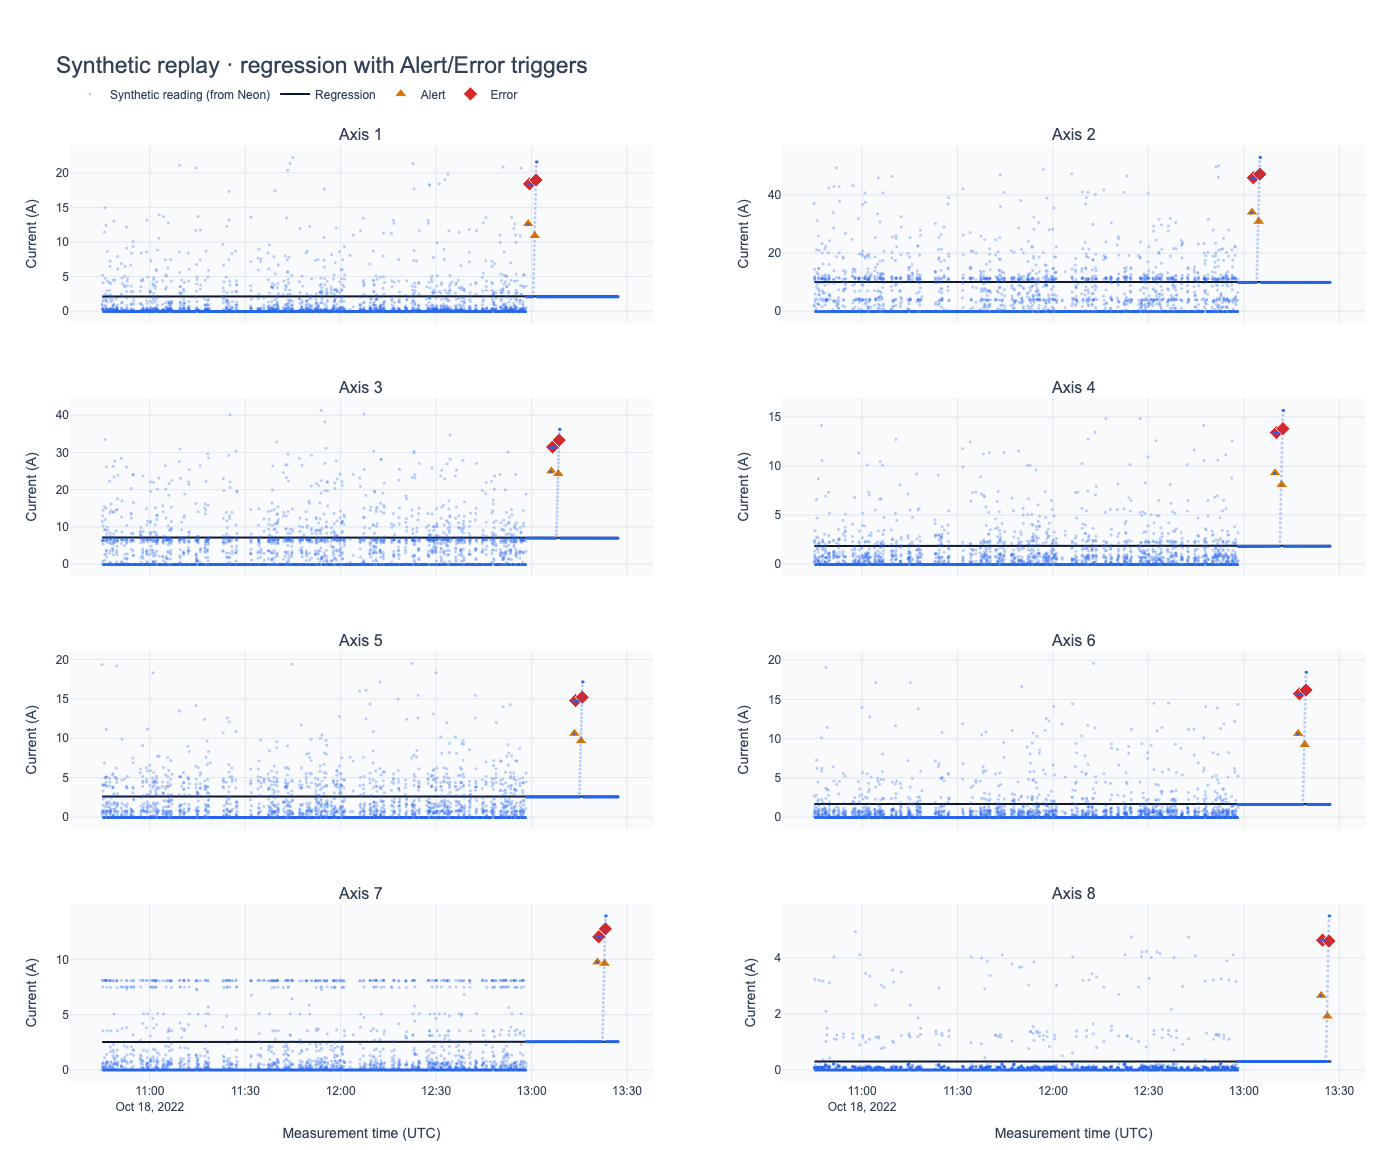

In [34]:
overview_fig = make_subplots(
    rows=4, cols=2, shared_xaxes="all",
    subplot_titles=[axis.replace("_", " ").title() for axis in AXIS_COLUMNS],
    vertical_spacing=0.08, horizontal_spacing=0.10,
)

for index, axis in enumerate(AXIS_COLUMNS):
    row, col = divmod(index, 2)
    row, col = row + 1, col + 1

    overview_fig.add_trace(go.Scattergl(
        x=db_test["reading_time"], y=db_test[axis],
        mode="markers", name="Synthetic reading (from Neon)",
        legendgroup="readings", showlegend=index == 0,
        marker=dict(size=3, opacity=0.3, color=CHART_COLORS["training"]),
        hovertemplate="%{x}<br>Current: %{y:.3f} A<extra>Reading</extra>",
    ), row=row, col=col)

    overview_fig.add_trace(go.Scatter(
        x=db_test["reading_time"], y=db_predictions[axis],
        mode="lines", name="Regression", legendgroup="regression",
        showlegend=index == 0,
        line=dict(color=CHART_COLORS["line"], width=2),
        hoverinfo="skip",
    ), row=row, col=col)

    current_by_time = db_test.set_index("reading_time")[axis]

    for level, symbol in [("Alert", "triangle-up"), ("Error", "diamond")]:
        events = db_events.loc[
            db_events["axis"].eq(axis) & db_events["level"].eq(level)
        ]
        overview_fig.add_trace(go.Scatter(
            x=events["triggered_at"],
            y=current_by_time.reindex(events["triggered_at"]).to_numpy(),
            mode="markers", name=level, legendgroup=level,
            showlegend=index == 0,
            marker=dict(
                color=EVENT_COLORS[level], symbol=symbol, size=11,
                line=dict(color="white", width=1),
            ),
            customdata=events[["observed_duration_seconds", "peak_residual_A"]].to_numpy(),
            hovertemplate=(
                "%{x}<br>Current: %{y:.3f} A"
                "<br>Duration: %{customdata[0]:.1f} s"
                "<br>Peak deviation: %{customdata[1]:.3f} A"
                "<extra>" + level + "</extra>"
            ),
        ), row=row, col=col)

    overview_fig.update_yaxes(title_text="Current (A)", row=row, col=col)

overview_fig.update_xaxes(title_text="Measurement time (UTC)", row=4)
style_chart(overview_fig, "Synthetic replay · regression with Alert/Error triggers")
show_chart(overview_fig, "synthetic_replay_overview", interactive=False)

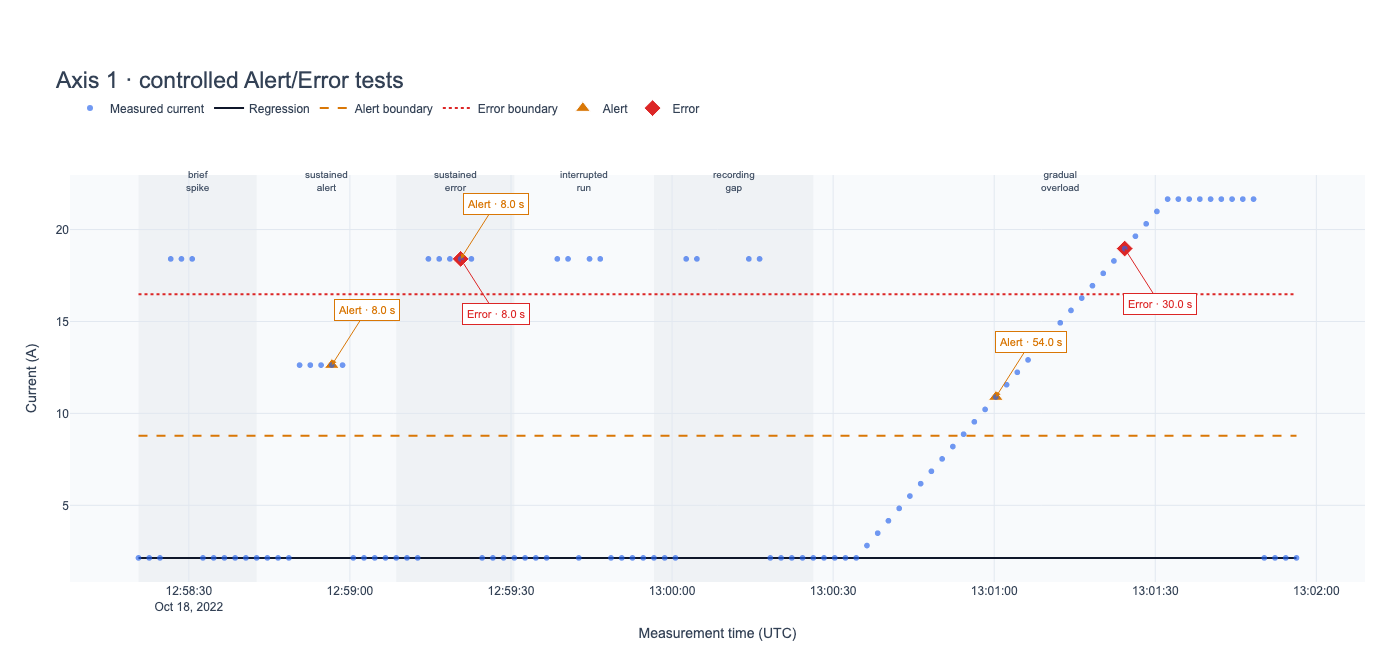

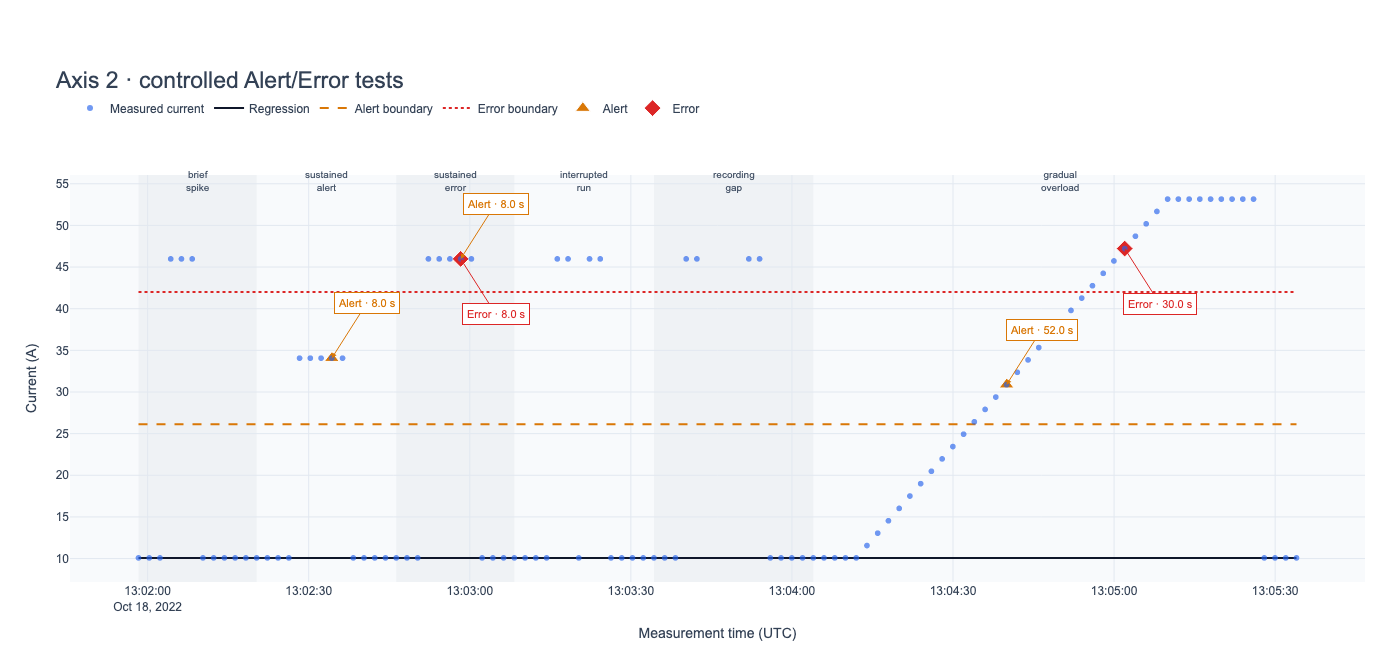

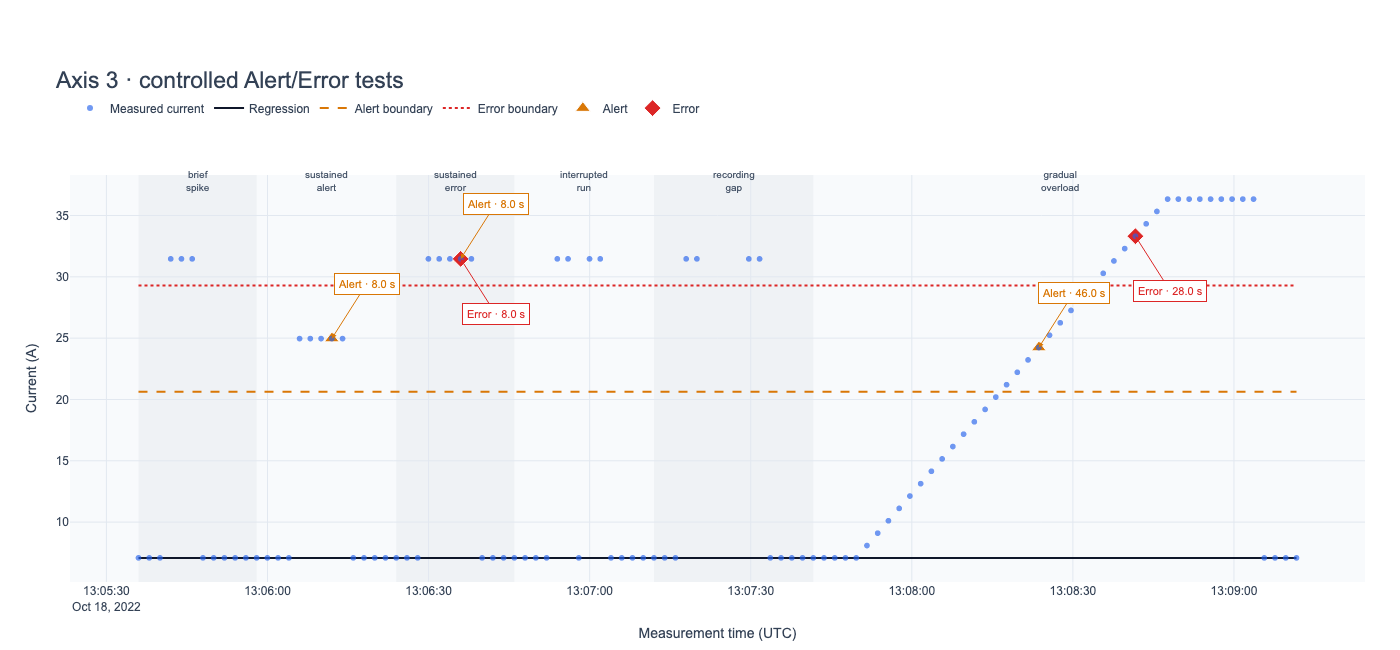

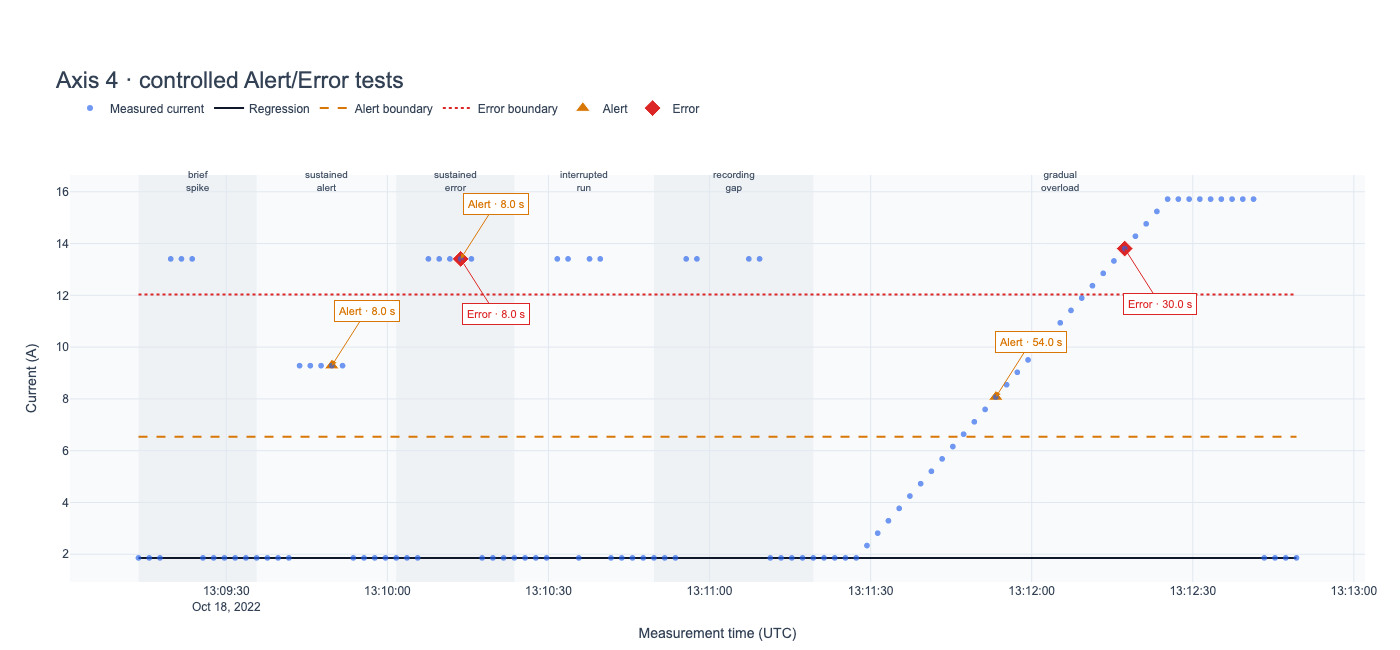

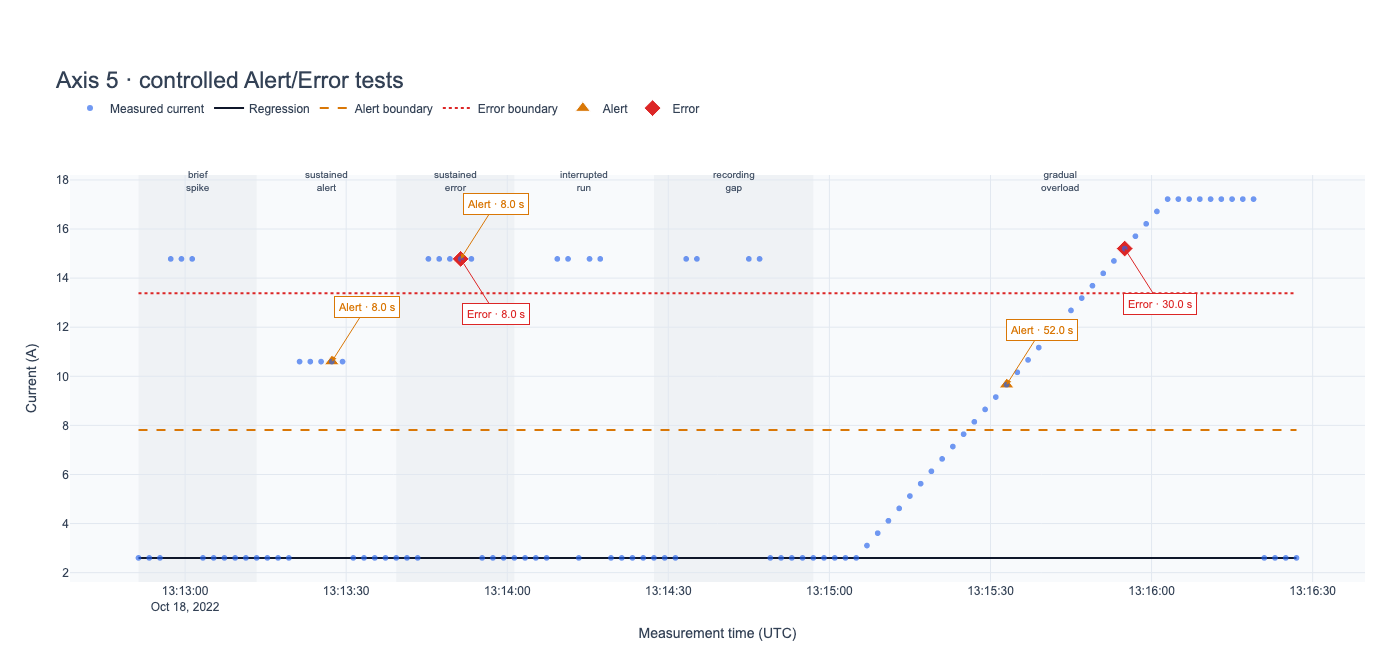

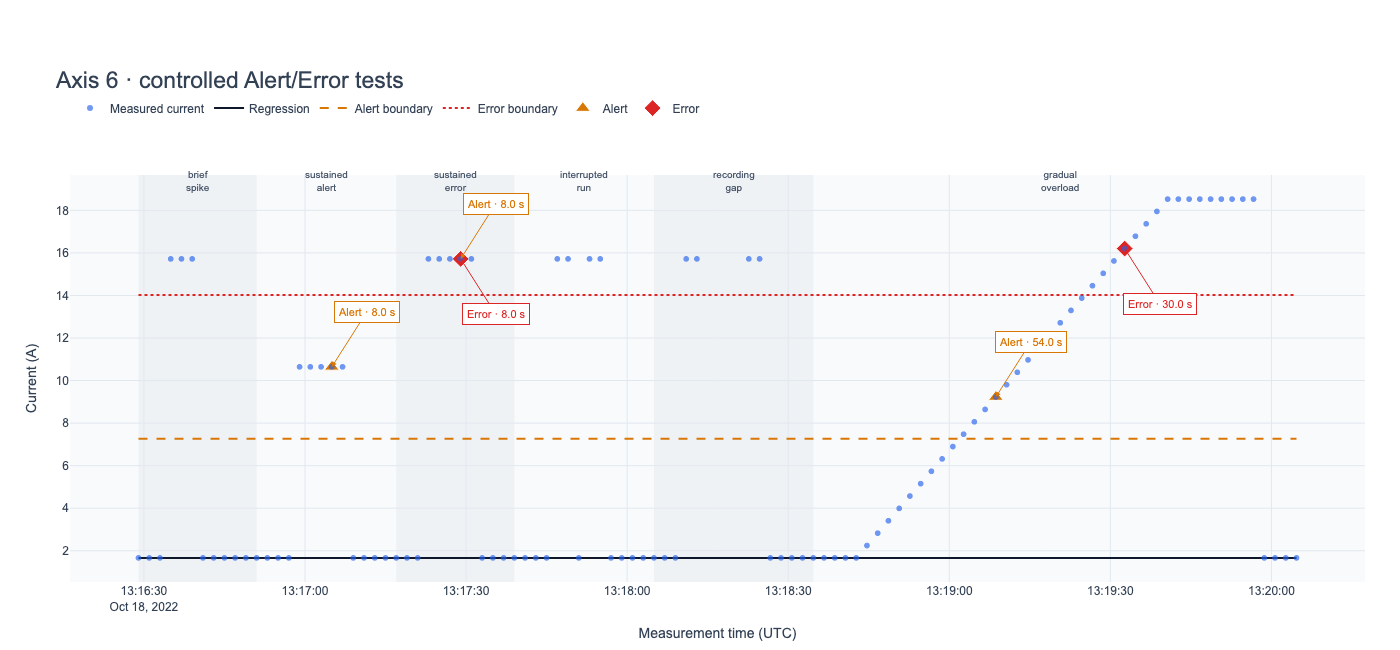

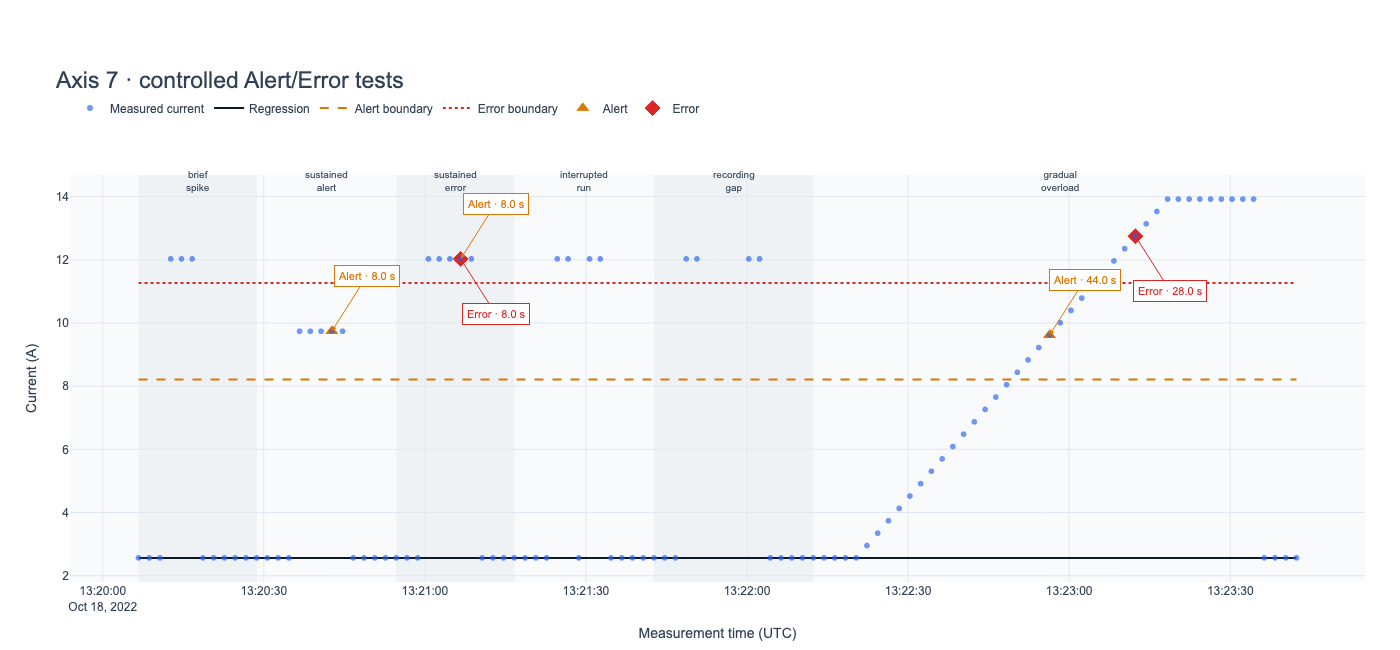

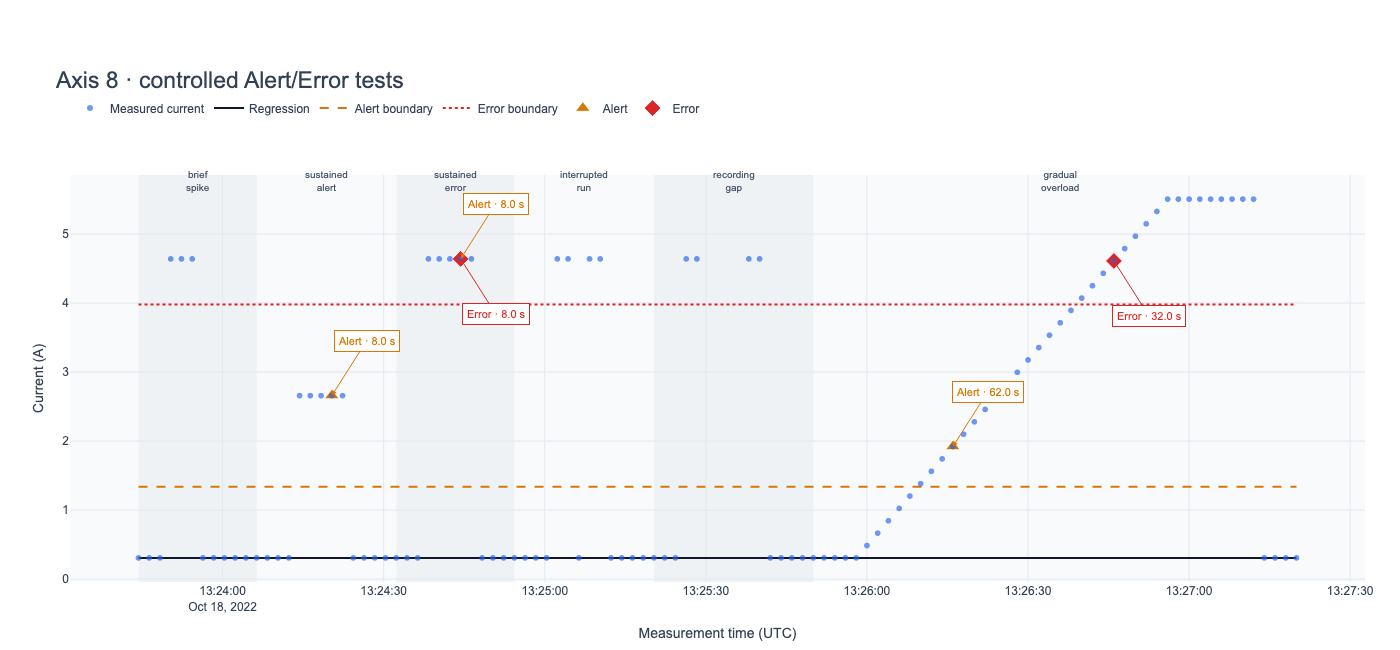

Saved eight interactive charts and PNGs to /Users/namy/Desktop/SCHOOL/Foundation of Machine Learning/LR/results/plots


In [35]:
for axis in AXIS_COLUMNS:
    figure = plot_axis_events(axis, controlled_only=True)
    show_chart(figure, f"{axis}_controlled_events")

    figure.write_html(
        PLOTS_DIR / f"{axis}_controlled_events.html",
        include_plotlyjs="cdn",
        full_html=True,
        config=CHART_CONFIG,
    )

print(f"Saved eight interactive charts and PNGs to {PLOTS_DIR}")

## 17 · Save the model and its settings

A prediction depends on more than a slope and intercept.

We also need the original time reference, the training scaling statistics,
the chosen thresholds, and the rule for handling recording gaps.

Saving these values makes our results inspectable and allows the model's
calculations to be reproduced without guessing which settings were used.

These exports describe the current experiment. They do not establish that
the model or thresholds are validated for use on a real robot.

In [36]:
import json

# Human-readable tables for the report and repository.
model_parameters.to_csv(
    RESULTS_DIR / "model_parameters.csv",
    index_label="axis",
)

model_metrics.to_csv(
    RESULTS_DIR / "model_metrics.csv",
    index=False,
)

residual_summary.to_csv(
    RESULTS_DIR / "residual_summary.csv",
    index_label="axis",
)

scaling_summary.to_csv(
    RESULTS_DIR / "training_scaling.csv",
    index_label="axis",
)

# Machine-readable configuration with full-precision values.
model_configuration = {
    "model_type": "eight independent ordinary least-squares regressions",
    "predictor": "elapsed_seconds",
    "fit_population": "active readings (at least one axis non-zero)",
    "MinC_rule": "training p95 of active residuals",
    "MaxC_rule": "max(training p99, MinC + 1 residual SD)",
    "target_unit": "A",
    "time_origin_utc": TIME_ORIGIN.isoformat(),
    "training_start_utc": train["reading_time"].min().isoformat(),
    "training_end_utc": train["reading_time"].max().isoformat(),
    "training_rows": len(train),
    "calibration_rows": len(calibration),
    "time_mean_seconds": float(time_mean),
    "time_std_seconds": float(time_std),
    "max_gap_seconds": float(MAX_GAP_SECONDS),
    "random_seed": RANDOM_SEED,
    "axes": {},
}

for axis in AXIS_COLUMNS:
    model_configuration["axes"][axis] = {
        "training_mean_A": float(current_mean[axis]),
        "training_std_A": float(current_std[axis]),
        "scale_used_A": float(current_scale[axis]),
        "intercept_z": float(models[axis]["intercept_z"]),
        "slope_z": float(models[axis]["slope_z"]),
        "intercept_A": float(models[axis]["intercept_A"]),
        "slope_A_per_second": float(
            models[axis]["slope_A_per_second"]
        ),
        "MinC_A": float(selected_thresholds.loc[axis, "MinC_A"]),
        "MaxC_A": float(selected_thresholds.loc[axis, "MaxC_A"]),
        "T_seconds": float(
            selected_thresholds.loc[axis, "T_seconds"]
        ),
        "MaxC_source": str(selected_thresholds.loc[axis, "MaxC_rule"]),
    }

configuration_path = RESULTS_DIR / "model_configuration.json"

configuration_path.write_text(
    json.dumps(model_configuration, indent=2, allow_nan=False),
    encoding="utf-8",
)

print("Saved model parameters, metrics, residuals, and configuration.")

Saved model parameters, metrics, residuals, and configuration.


## 18 · Findings

**The model.** Fitted on 10,567 active training readings, every slope is within ±0.03 A per hour and R² is about zero. Over these 22.5 hours no joint drifts measurably, so each line is simply that joint's typical working current (Axis 2 ≈ 10.0 A, Axis 3 ≈ 7.8 A, Axis 8 ≈ 0.27 A). Calibration MAE and RMSE are within about 10% of training, and the outlier shares are nearly identical in both periods: the later hours behave like the earlier ones.

**Classic outlier rules are not enough on their own.** The IQR rule flags 3.6–13.5% of working readings on seven axes, and the 3 SD rule about 2–3%. The residuals are strongly right-skewed (each work cycle has peaks), so those "outliers" are normal work. On Axis 7 the IQR rule finds nothing (current ceiling), and on Axis 8 its fence is negative. This is why the rules use percentiles **plus** duration.

**Chosen thresholds** (amps above the regression line, T = 5 s, recording gaps over 5.7 s reset the timers):

| Axis | MinC (Alert) | MaxC (Error) | MaxC source |
|---|---|---|---|
| 1 | 6.64 | 14.34 | p99 |
| 2 | 16.04 | 31.93 | p99 |
| 3 | 13.55 | 22.21 | p99 |
| 4 | 4.68 | 10.17 | p99 |
| 5 | 5.21 | 10.79 | p99 |
| 6 | 5.60 | 12.36 | p99 |
| 7 | 5.65 | 8.70 | MinC + 1 SD (current ceiling) |
| 8 | 1.03 | 3.67 | p99 |

**What the rules did:**

- **Healthy history:** 2 Alerts in 18 hours of training data (both Axis 6, both gap-bridged), none in the 4.4-hour calibration period, and no Errors.
- **Synthetic stream through Neon:** 4,840 readings were inserted, queried back and scored live. The resampled healthy background produced **no** events. All 48 controlled scenarios behaved as expected. Brief spikes, interrupted runs and gap-split runs were correctly ignored.
- **Logged:** 40 events (24 Alerts, 16 Errors) in `results/events.csv` and the Neon `alert_events` table. The live detector's triggers matched the completed-run calculation exactly.
- **Gradual overload:** the Alert fires first and the Error 16–30 s later. That is the escalation a maintenance team would want: inspect, then stop.

**Predictive-maintenance reading.** The robot shows no sign of degradation in this window, and the rules agree: they stay quiet on healthy data and react within 6 seconds to a sustained overload. The value of the model is the baseline. Collected continuously and refitted periodically, a slope that starts to climb on Axis 2 or 3 would be the early, months-scale signal of torque-tube wear, and the Alert/Error rules catch the acute version.

**Limitations.**

- There are no fault labels, so precision and recall cannot be measured.
- Thresholds are in amps, because the data has no voltage to derive kWh.
- Calibration data helped choose the rules, so it is not an independent test.
- Synthetic background data reuses training blocks.
- A run of two readings across a near-limit sampling gap can satisfy T. A refinement would also require a minimum number of readings.